In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator, interp1d
import pickle

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/'

In [3]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [4]:
t_Myr_sec = 3.1689E-14 # Conversion from seconds to Myr

# Functions for PIE temperature, cooling/recombination time

Load cooling times and temperatures saved for PIE (main grid run)

In [5]:
# Unique grids in density/metallicity
log_hdens_arr = np.arange(-5, 1.25, 0.25)
log_metals_arr = np.arange(-3, 1.25, 0.25)
N_pts = len(log_hdens_arr)*len(log_metals_arr)

log_hdens_sub_arr = np.arange(-4.25, 1.25, 0.25)
log_metals_sub_arr = np.arange(-0.25, 1.25, 0.25)

In [6]:
# Grid of cooling times, in seconds, need to convert to Myr
# Index only accesses for unique density/metallicities
t_cool_grid = np.loadtxt(rootdir+'cloudy_grids/t_cool.txt', delimiter=',')[2::3]*t_Myr_sec
t_cool_grid = t_cool_grid.reshape(len(log_hdens_arr),len(log_metals_arr))

# Store these into a dictionary
logt_cool_dict = {}

# Measurements after adding blackbody heating

for i in range(len(log_hdens_arr)):
    for j in range(len(log_metals_arr)):
        log_hdens = log_hdens_arr[i]
        log_metals = log_metals_arr[j]
        logt_cool_dict[(log_hdens,log_metals)] = np.log10(t_cool_grid[i,j])

t_cool_sub_grid = np.loadtxt(rootdir+'cloudy_grids/t_cool_sub.txt', delimiter=',')[2::3]*t_Myr_sec
t_cool_sub_grid = t_cool_sub_grid.reshape(len(log_hdens_sub_arr),len(log_metals_sub_arr))

logt_cool_sub_dict = {}

for i in range(len(log_hdens_sub_arr)):
    for j in range(len(log_metals_sub_arr)):
        log_hdens = log_hdens_sub_arr[i]
        log_metals = log_metals_sub_arr[j]
        logt_cool_sub_dict[(log_hdens,log_metals)] = np.log10(t_cool_sub_grid[i,j])

In [7]:
# Load in final temperatures and reshape
logT_grid = np.loadtxt(rootdir+'cloudy_grids/final_flat_logT.dat')[:N_pts]
logT_grid = logT_grid.reshape(len(log_hdens_arr),len(log_metals_arr))

In [8]:
logt_cool_grid = np.zeros(t_cool_grid.shape)

for i in range(len(log_hdens_arr)):
    for j in range(len(log_metals_arr)):
        log_hdens = log_hdens_arr[i]
        log_metals = log_metals_arr[j]
        if logT_grid[i,j] == 4.: # Needed to add blackbody heating
            logt_cool_grid[i,j] = logt_cool_sub_dict[(log_hdens,log_metals)]
        else:
            logt_cool_grid[i,j] = logt_cool_dict[(log_hdens,log_metals)]

Interpolate temperatures and cooling times

In [9]:
logT_interp = RegularGridInterpolator((log_hdens_arr, log_metals_arr), logT_grid)
logt_cool_interp = RegularGridInterpolator((log_hdens_arr, log_metals_arr), logt_cool_grid)

Interpolate recombination times

In [10]:
# From CLOUDY calculations
logT_rec_grid = np.array([4. , 4.2, 4.4, 4.6, 4.8, 5. , 5.2, 5.4, 5.6, 5.8, 6. , 6.2, 6.4,
        6.6, 6.8, 7. , 7.2, 7.4, 7.6, 7.8, 8. ])

logq_rec_grid = np.log10(np.array([5.14e-12, 3.75e-12, 2.72e-12, 1.96e-12, 1.40e-12, 9.95e-13,
        6.99e-13, 4.86e-13, 3.34e-13, 2.26e-13, 1.50e-13, 9.80e-14,
        6.27e-14, 3.93e-14, 2.41e-14, 1.44e-14, 8.47e-15, 4.86e-15,
        2.74e-15, 1.52e-15, 1.52e-15]))

In [11]:
logq_rec_interp = interp1d(logT_rec_grid, logq_rec_grid, fill_value='extrapolate')

In [12]:
def logt_rec(log_hdens, logT, logq_rec_interp):
    
    logq = logq_rec_interp(logT)
    logt_rec = np.log10((10**log_hdens*10**logq)**-1*t_Myr_sec)
    
    return logt_rec

Functions to get distributions of $T$, $t_\mathrm{rec}$ and $t_\mathrm{cool}/t_\mathrm{rec}$

In [13]:
def get_cooling_dist(log_hdens_samples, log_metals_samples, logq_rec_interp, logt_cool_interp):
    
    # Distribution of PIE temperatures
    logT_samples = logT_interp((log_hdens_samples, log_metals_samples))
    
    # Distribution of recombination times
    logt_rec_samples = logt_rec(log_hdens_samples, logT_samples, logq_rec_interp)
    
    # Distribution of cooling times
    logt_cool_samples = logt_cool_interp((log_hdens_samples, log_metals_samples))
    
    return np.array(logT_samples), np.array(logt_rec_samples), np.array(logt_cool_samples)

In [14]:
loaddir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/'

Diagnostic plots

In [15]:
log_hdens_test_arr = np.arange(-4.6, -2.3, 0.05)

Text(0, 0.5, '$\\log(T/\\mathrm{K})$')

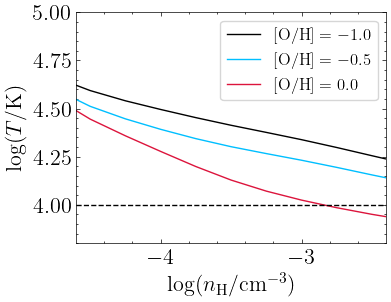

In [16]:
fig, ax = plt.subplots(1,figsize=(4,3))
ax.plot(log_hdens_test_arr, logT_interp((log_hdens_test_arr,-1.0)), label=r'$[\mathrm{O/H}]=-1.0$')
ax.plot(log_hdens_test_arr, logT_interp((log_hdens_test_arr,-0.5)), label=r'$[\mathrm{O/H}]=-0.5$')
ax.plot(log_hdens_test_arr, logT_interp((log_hdens_test_arr,0.0)), label=r'$[\mathrm{O/H}]=0.0$')

ax.axhline(4.0,linestyle='--')
ax.set_xlim(-4.6,-2.4)
ax.set_ylim(3.8,5.0)

ax.legend()

ax.set_xlabel(r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})$')
ax.set_ylabel(r'$\log(T/\mathrm{K})$')

Text(0, 0.5, '$\\log(t_\\mathrm{cool}/t_\\mathrm{rec})$')

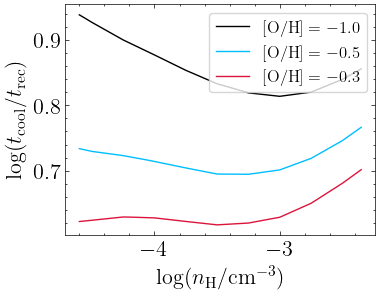

In [17]:
fig, ax = plt.subplots(1,figsize=(4,3))

ax.plot(log_hdens_test_arr,
        logt_cool_interp((log_hdens_test_arr,-1.0))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-1.0)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=-1.0$')

ax.plot(log_hdens_test_arr,
        logt_cool_interp((log_hdens_test_arr,-0.5))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-0.5)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=-0.5$')

ax.plot(log_hdens_test_arr,
        logt_cool_interp((log_hdens_test_arr,-0.3))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-0.3)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=-0.3$')

ax.legend()
ax.set_xlabel(r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})$')
ax.set_ylabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec})$')

In [18]:
log_metals_test_arr = np.arange(-3.0, 1., 0.1)

Text(0, 0.5, '$\\log(t_\\mathrm{cool}/t_\\mathrm{rec})$')

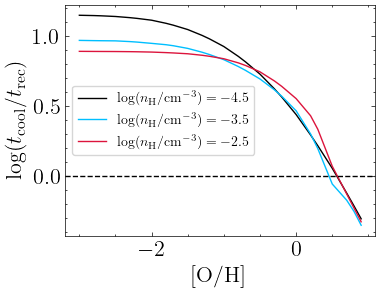

In [19]:
fig, ax = plt.subplots(1,figsize=(4,3))

ax.plot(log_metals_test_arr,
        logt_cool_interp((-4.5,log_metals_test_arr))-logt_rec(-4.5,logT_interp((-4.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.5$')

ax.plot(log_metals_test_arr,
        logt_cool_interp((-3.5,log_metals_test_arr))-logt_rec(-3.5,logT_interp((-3.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$')

ax.plot(log_metals_test_arr,
        logt_cool_interp((-2.5,log_metals_test_arr))-logt_rec(-2.5,logT_interp((-2.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-2.5$')

ax.axhline(0, linestyle='--')

ax.legend(fontsize=10)
ax.set_xlabel(r'$\mathrm{[O/H]}$')
ax.set_ylabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec})$')

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_37421/1698747624.py:4: RuntimeWarning: invalid value encountered in reciprocal
  logt_rec = np.log10((10**log_hdens*10**logq)**-1*t_Myr_sec)


Text(0, 0.5, '$\\log(t_\\mathrm{cool}/t_\\mathrm{rec})$')

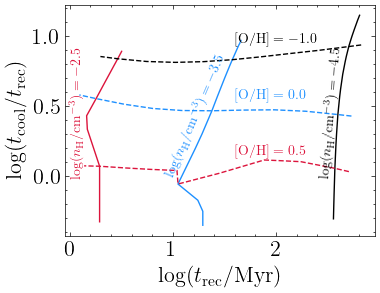

In [20]:
fig, ax = plt.subplots(1,figsize=(4,3))

ax.plot(logt_rec(-4.5,logT_interp((-4.5,log_metals_test_arr)),logq_rec_interp),
        logt_cool_interp((-4.5,log_metals_test_arr))-logt_rec(-4.5,logT_interp((-4.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.5$',color='black')

ax.text(2.4,0.0,r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.5$',fontsize=10, rotation=85, color='black')

ax.plot(logt_rec(-3.5,logT_interp((-3.5,log_metals_test_arr)),logq_rec_interp),
        logt_cool_interp((-3.5,log_metals_test_arr))-logt_rec(-3.5,logT_interp((-3.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$',color='dodgerblue')

ax.text(0.9,0.0,r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$',fontsize=10, rotation=67, color='dodgerblue')

ax.plot(logt_rec(-2.5,logT_interp((-2.5,log_metals_test_arr)),logq_rec_interp),
        logt_cool_interp((-2.5,log_metals_test_arr))-logt_rec(-2.5,logT_interp((-2.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-2.5$',color='crimson')

ax.text(0.0,0.0,r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-2.5$',fontsize=10, rotation=90, color='crimson')

ax.plot(logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-1.0)),logq_rec_interp),
        logt_cool_interp((log_hdens_test_arr,-1.0))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-1.0)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=-1.0$',color='black', linestyle='--')

ax.text(1.6,0.95,r'$\mathrm{[O/H]}=-1.0$',fontsize=10)

ax.plot(logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,0.0)),logq_rec_interp),
        logt_cool_interp((log_hdens_test_arr,0.0))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,0.0)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=0.0$',color='dodgerblue', linestyle='--')

ax.text(1.6,0.55,r'$\mathrm{[O/H]}=0.0$',fontsize=10,color='dodgerblue')

ax.plot(logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,0.5)),logq_rec_interp),
        logt_cool_interp((log_hdens_test_arr,0.5))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,0.5)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=0.5$',color='crimson', linestyle='--')

ax.text(1.6,0.15,r'$\mathrm{[O/H]}=0.5$',fontsize=10,color='crimson')

ax.set_xlabel(r'$\log(t_\mathrm{rec}/\mathrm{Myr})$')
ax.set_ylabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec})$')

# z=0.67, PIE

## c1

In [21]:
z_067_c1_PIE_samples = pd.read_csv(loaddir+'z=0.67545705/cloudy_fits/two_phase.csv')

### c1H

In [22]:
z_067_c1H_PIE_logT, z_067_c1H_PIE_logt_rec, z_067_c1H_PIE_logt_cool = get_cooling_dist(z_067_c1_PIE_samples['log_hdens_p1'],
                                                                                             z_067_c1_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([   52.,   189.,   500.,   782.,  1829.,  7645., 36400., 28803.,
         3605.,   195.]),
 array([4.14892624, 4.17447734, 4.20002843, 4.22557952, 4.25113062,
        4.27668171, 4.3022328 , 4.32778389, 4.35333499, 4.37888608,
        4.40443717]),
 <BarContainer object of 10 artists>)

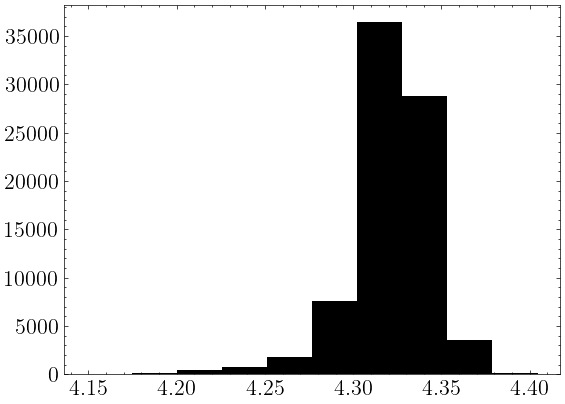

In [23]:
plt.hist(z_067_c1H_PIE_logT)

In [24]:
get_quantiles(z_067_c1H_PIE_logT)

4.32 -0.02 0.02


(array([   55.,   214.,   616.,  1014.,  1958.,  5136., 19998., 38199.,
        12129.,   681.]),
 array([0.28839189, 0.3999908 , 0.51158971, 0.62318862, 0.73478753,
        0.84638644, 0.95798535, 1.06958426, 1.18118318, 1.29278209,
        1.404381  ]),
 <BarContainer object of 10 artists>)

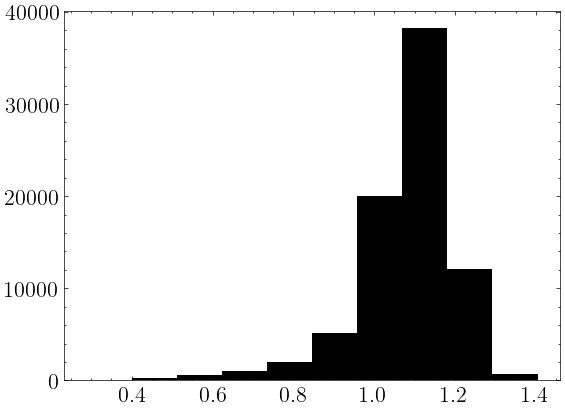

In [25]:
plt.hist(z_067_c1H_PIE_logt_rec)

In [26]:
get_quantiles(z_067_c1H_PIE_logt_rec)

1.1 -0.11 0.08


(array([   43.,   725., 12537., 39596., 20812.,  4562.,  1213.,   310.,
          122.,    80.]),
 array([0.74203849, 0.75382403, 0.76560958, 0.77739513, 0.78918068,
        0.80096622, 0.81275177, 0.82453732, 0.83632286, 0.84810841,
        0.85989396]),
 <BarContainer object of 10 artists>)

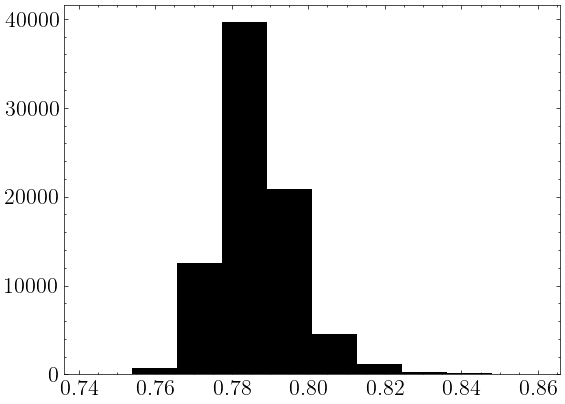

In [27]:
plt.hist(z_067_c1H_PIE_logt_cool-z_067_c1H_PIE_logt_rec)

In [28]:
get_quantiles(z_067_c1H_PIE_logt_cool-z_067_c1H_PIE_logt_rec)

0.79 -0.01 0.01


### c1L

In [29]:
z_067_c1L_PIE_logT, z_067_c1L_PIE_logt_rec, z_067_c1L_PIE_logt_cool = get_cooling_dist(z_067_c1_PIE_samples['log_hdens_p2'],
                                                                                             z_067_c1_PIE_samples['log_metals_p2'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([  176.,   188.,   497.,  1400.,  5387., 14232., 20700., 20018.,
        12900.,  4502.]),
 array([3.9641044 , 4.01856603, 4.07302765, 4.12748928, 4.1819509 ,
        4.23641253, 4.29087415, 4.34533578, 4.3997974 , 4.45425903,
        4.50872065]),
 <BarContainer object of 10 artists>)

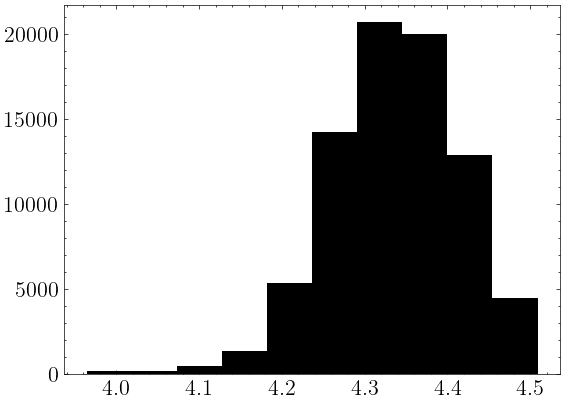

In [30]:
plt.hist(z_067_c1L_PIE_logT)

In [31]:
get_quantiles(z_067_c1L_PIE_logT)

4.34 -0.08 0.08


(array([  100.,   625.,  2548.,  7890., 19118., 22873., 16277.,  7910.,
         2508.,   151.]),
 array([1.59020635, 1.65025665, 1.71030696, 1.77035726, 1.83040757,
        1.89045787, 1.95050818, 2.01055848, 2.07060879, 2.13065909,
        2.1907094 ]),
 <BarContainer object of 10 artists>)

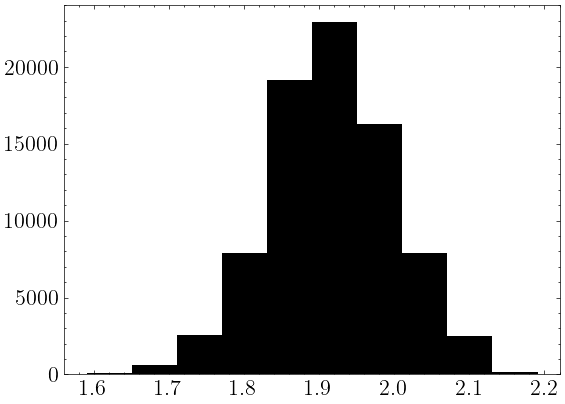

In [32]:
plt.hist(z_067_c1L_PIE_logt_rec)

In [33]:
get_quantiles(z_067_c1L_PIE_logt_rec)

1.92 -0.08 0.08


(array([   66.,   137.,   113.,   400.,  1266.,  5092., 14377., 23108.,
        24937., 10504.]),
 array([-0.21477461, -0.10357619,  0.00762224,  0.11882066,  0.23001908,
         0.34121751,  0.45241593,  0.56361435,  0.67481278,  0.7860112 ,
         0.89720962]),
 <BarContainer object of 10 artists>)

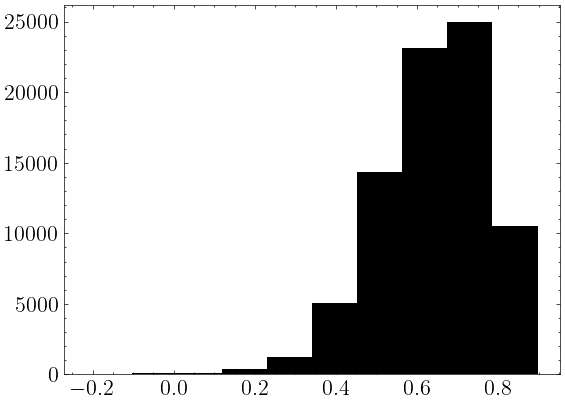

In [34]:
plt.hist(z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_rec)

In [35]:
get_quantiles(z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_rec)

0.66 -0.15 0.12


# z=1.04, PIE

## c1

In [36]:
z_104_c1_PIE_samples = pd.read_csv(loaddir+'z=1.04430667/cloudy_fits/one_phase_c1.csv')

In [37]:
z_104_c1_PIE_logT, z_104_c1_PIE_logt_rec, z_104_c1_PIE_logt_cool = get_cooling_dist(z_104_c1_PIE_samples['log_hdens'],
                                                                                    z_104_c1_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([  362.,   899.,  2181.,  9018., 31285., 28951.,  5749.,  1022.,
          475.,    58.]),
 array([3.81398646, 3.87794793, 3.94190939, 4.00587085, 4.06983232,
        4.13379378, 4.19775524, 4.26171671, 4.32567817, 4.38963963,
        4.4536011 ]),
 <BarContainer object of 10 artists>)

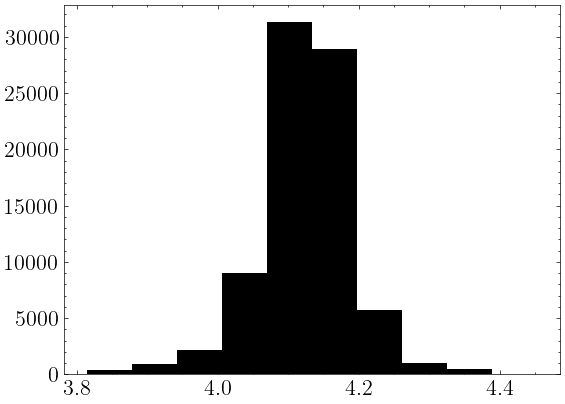

In [38]:
plt.hist(z_104_c1_PIE_logT)

In [39]:
get_quantiles(z_104_c1_PIE_logT)

4.13 -0.06 0.05


(array([9.8000e+01, 1.4030e+03, 1.6821e+04, 5.3373e+04, 7.0090e+03,
        7.2800e+02, 3.1600e+02, 1.9100e+02, 5.3000e+01, 8.0000e+00]),
 array([0.35906317, 0.56805963, 0.77705609, 0.98605256, 1.19504902,
        1.40404548, 1.61304194, 1.8220384 , 2.03103487, 2.24003133,
        2.44902779]),
 <BarContainer object of 10 artists>)

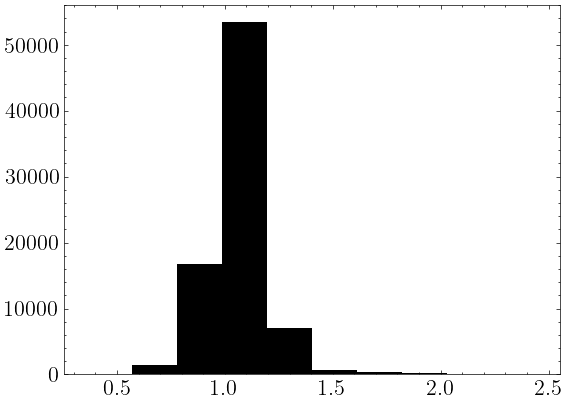

In [40]:
plt.hist(z_104_c1_PIE_logt_rec)

In [41]:
get_quantiles(z_104_c1_PIE_logt_rec)

1.06 -0.1 0.11


(array([7.0000e+00, 4.2000e+01, 4.7300e+02, 1.6860e+03, 6.4020e+03,
        3.0482e+04, 3.2888e+04, 6.8610e+03, 1.0480e+03, 1.1100e+02]),
 array([0.17120889, 0.23405672, 0.29690456, 0.35975239, 0.42260022,
        0.48544806, 0.54829589, 0.61114372, 0.67399156, 0.73683939,
        0.79968722]),
 <BarContainer object of 10 artists>)

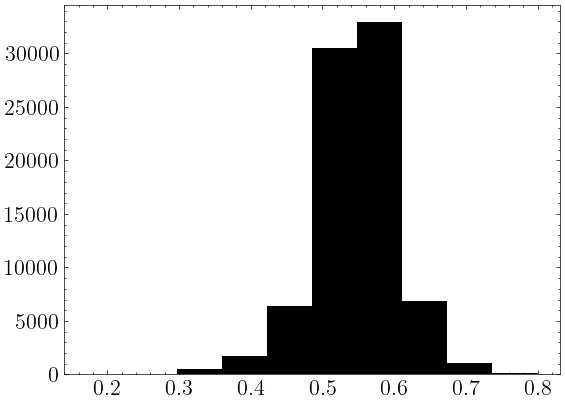

In [42]:
plt.hist(z_104_c1_PIE_logt_cool-z_104_c1_PIE_logt_rec)

In [43]:
get_quantiles(z_104_c1_PIE_logt_cool-z_104_c1_PIE_logt_rec)

0.55 -0.05 0.05


## c2

In [44]:
z_104_c2_PIE_samples = pd.read_csv(loaddir+'z=1.04430667/cloudy_fits/one_phase_c2.csv')

In [45]:
z_104_c2_PIE_logT, z_104_c2_PIE_logt_rec, z_104_c2_PIE_logt_cool = get_cooling_dist(z_104_c2_PIE_samples['log_hdens'],
                                                                                    z_104_c2_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([   18.,    25.,   672., 13804., 13786., 17334., 17142., 14186.,
         2923.,   110.]),
 array([3.72511584, 3.77922312, 3.83333039, 3.88743767, 3.94154495,
        3.99565223, 4.0497595 , 4.10386678, 4.15797406, 4.21208134,
        4.26618862]),
 <BarContainer object of 10 artists>)

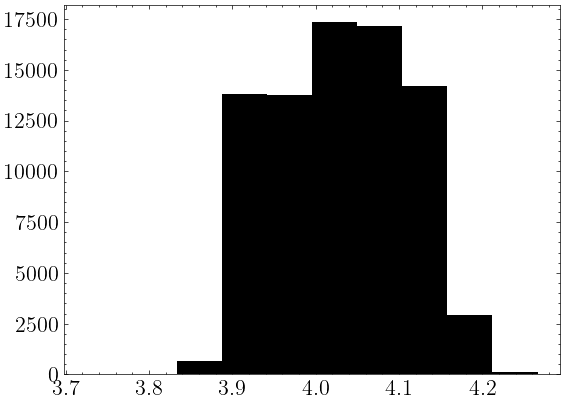

In [46]:
plt.hist(z_104_c2_PIE_logT)

In [47]:
get_quantiles(z_104_c2_PIE_logT)

4.03 -0.1 0.08


(array([1.4500e+02, 2.0700e+03, 8.7840e+03, 1.6547e+04, 2.2571e+04,
        1.8489e+04, 8.9280e+03, 2.2060e+03, 2.3900e+02, 2.1000e+01]),
 array([0.8408098 , 0.92068394, 1.00055809, 1.08043224, 1.16030639,
        1.24018053, 1.32005468, 1.39992883, 1.47980298, 1.55967713,
        1.63955127]),
 <BarContainer object of 10 artists>)

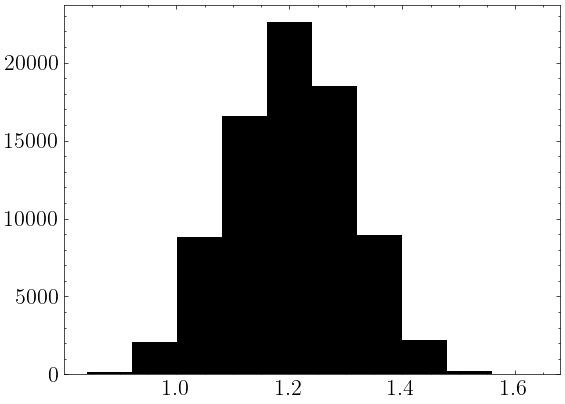

In [48]:
plt.hist(z_104_c2_PIE_logt_rec)

In [49]:
get_quantiles(z_104_c2_PIE_logt_rec)

1.21 -0.11 0.11


(array([   35.,   233.,  2011.,  5039., 11126., 16682., 18616., 18422.,
         7302.,   534.]),
 array([0.01369833, 0.07322171, 0.13274508, 0.19226846, 0.25179184,
        0.31131522, 0.3708386 , 0.43036197, 0.48988535, 0.54940873,
        0.60893211]),
 <BarContainer object of 10 artists>)

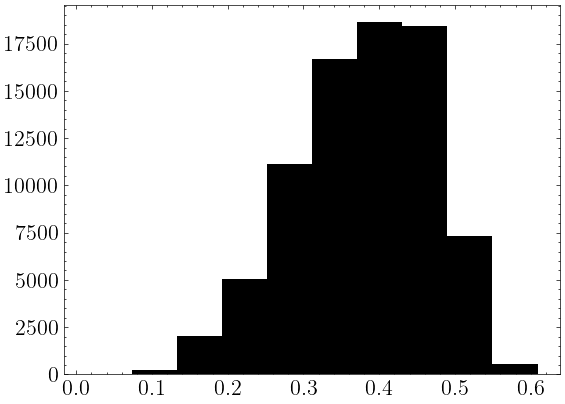

In [50]:
plt.hist(z_104_c2_PIE_logt_cool-z_104_c2_PIE_logt_rec)

In [51]:
get_quantiles(z_104_c2_PIE_logt_cool-z_104_c2_PIE_logt_rec)

0.39 -0.1 0.09


## c3

In [52]:
z_104_c3_PIE_samples = pd.read_csv(loaddir+'z=1.04430667/cloudy_fits/two_phase_c3.csv')

### c3H

In [53]:
z_104_c3H_PIE_logT, z_104_c3H_PIE_logt_rec, z_104_c3H_PIE_logt_cool = get_cooling_dist(z_104_c3_PIE_samples['log_hdens_p1'],
                                                                                             z_104_c3_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([   31.,   127.,   431.,  1807.,  8434., 23950., 22884., 14638.,
         6563.,  1135.]),
 array([3.89066114, 3.95072378, 4.01078642, 4.07084906, 4.1309117 ,
        4.19097434, 4.25103698, 4.31109962, 4.37116226, 4.4312249 ,
        4.49128754]),
 <BarContainer object of 10 artists>)

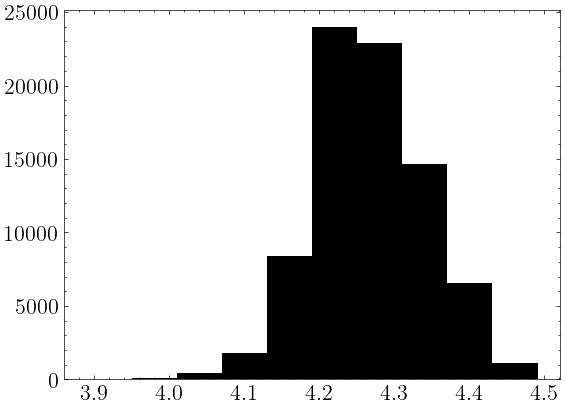

In [54]:
plt.hist(z_104_c3H_PIE_logT)

In [55]:
get_quantiles(z_104_c3H_PIE_logT)

4.26 -0.06 0.08


(array([   84.,   656.,  3649.,  8501., 14848., 19770., 19174., 10969.,
         2074.,   275.]),
 array([0.23812144, 0.38623976, 0.53435807, 0.68247638, 0.83059469,
        0.978713  , 1.12683131, 1.27494962, 1.42306793, 1.57118624,
        1.71930455]),
 <BarContainer object of 10 artists>)

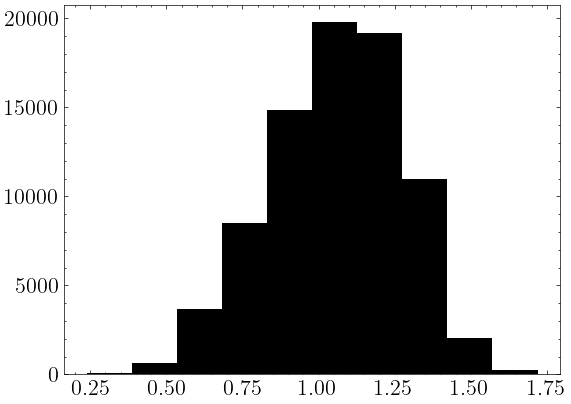

In [56]:
plt.hist(z_104_c3H_PIE_logt_rec)

In [57]:
get_quantiles(z_104_c3H_PIE_logt_rec)

1.07 -0.25 0.21


(array([1.3000e+01, 1.5800e+02, 1.3720e+03, 8.0980e+03, 1.8010e+04,
        1.7491e+04, 1.4580e+04, 1.0911e+04, 7.0640e+03, 2.3030e+03]),
 array([0.43222045, 0.48269536, 0.53317028, 0.58364519, 0.6341201 ,
        0.68459501, 0.73506992, 0.78554483, 0.83601975, 0.88649466,
        0.93696957]),
 <BarContainer object of 10 artists>)

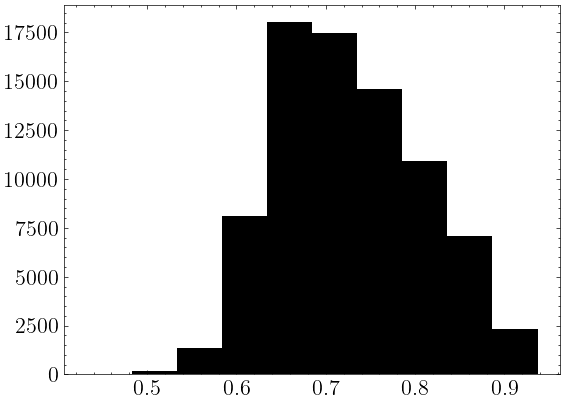

In [58]:
plt.hist(z_104_c3H_PIE_logt_cool-z_104_c3H_PIE_logt_rec)

In [59]:
get_quantiles(z_104_c3H_PIE_logt_cool-z_104_c3H_PIE_logt_rec)

0.72 -0.08 0.1


### c3L

In [60]:
z_104_c3L_PIE_logT, z_104_c3L_PIE_logt_rec, z_104_c3L_PIE_logt_cool = get_cooling_dist(z_104_c3_PIE_samples['log_hdens_p2'],
                                                                                             z_104_c3_PIE_samples['log_metals_p2'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([  397.,  2428.,  7501., 11623., 15622., 22052., 13631.,  4883.,
         1583.,   280.]),
 array([3.66771948, 3.77326077, 3.87880207, 3.98434336, 4.08988466,
        4.19542595, 4.30096725, 4.40650854, 4.51204983, 4.61759113,
        4.72313242]),
 <BarContainer object of 10 artists>)

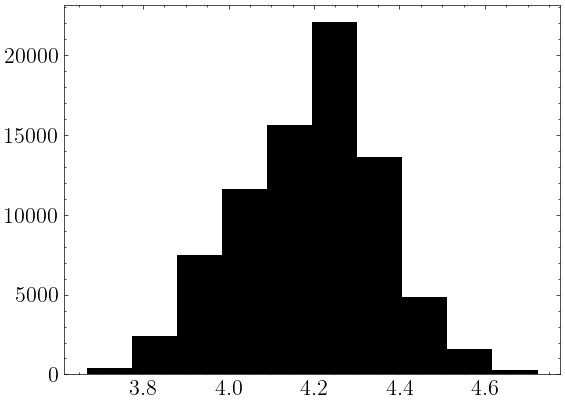

In [61]:
plt.hist(z_104_c3L_PIE_logT)

In [62]:
get_quantiles(z_104_c3L_PIE_logT)

4.21 -0.21 0.14


(array([ 1269., 11862., 27257., 21800., 12100.,  3878.,  1318.,   367.,
           96.,    53.]),
 array([1.05237637, 1.27536726, 1.49835815, 1.72134904, 1.94433993,
        2.16733082, 2.39032171, 2.61331259, 2.83630348, 3.05929437,
        3.28228526]),
 <BarContainer object of 10 artists>)

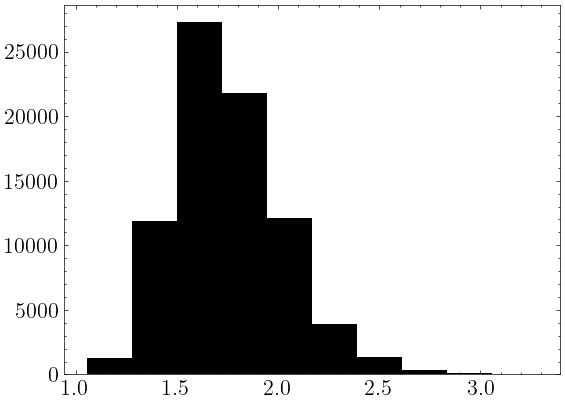

In [63]:
plt.hist(z_104_c3L_PIE_logt_rec)

In [64]:
get_quantiles(z_104_c3L_PIE_logt_rec)

1.72 -0.22 0.3


(array([ 1578.,  2620.,  5156.,  6397.,  8626., 16930., 20789., 12993.,
         3914.,   997.]),
 array([-0.47397268, -0.31894143, -0.16391017, -0.00887891,  0.14615234,
         0.3011836 ,  0.45621485,  0.61124611,  0.76627737,  0.92130862,
         1.07633988]),
 <BarContainer object of 10 artists>)

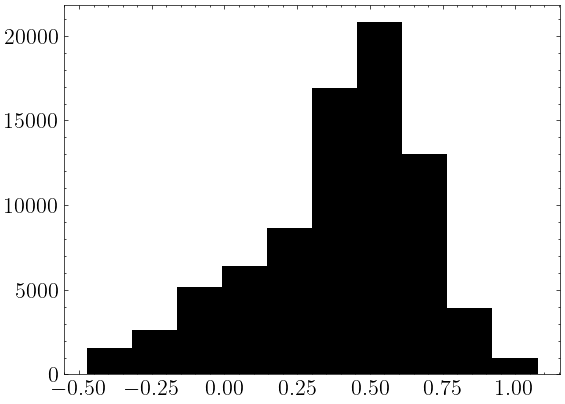

In [65]:
plt.hist(z_104_c3L_PIE_logt_cool-z_104_c3L_PIE_logt_rec)

In [66]:
get_quantiles(z_104_c3L_PIE_logt_cool-z_104_c3L_PIE_logt_rec)

0.45 -0.37 0.21


## c4

In [67]:
z_104_c4_PIE_samples = pd.read_csv(loaddir+'z=1.04430667/cloudy_fits/two_phase_c4.csv')

### c4H

In [68]:
z_104_c4H_PIE_logT, z_104_c4H_PIE_logt_rec, z_104_c4H_PIE_logt_cool = get_cooling_dist(z_104_c4_PIE_samples['log_hdens_p1'],
                                                                                             z_104_c4_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([2.8000e+01, 1.0000e+02, 2.6000e+02, 9.4000e+02, 2.9850e+03,
        1.0301e+04, 2.5472e+04, 2.8194e+04, 1.0542e+04, 1.1780e+03]),
 array([3.8044359 , 3.8709105 , 3.93738509, 4.00385968, 4.07033428,
        4.13680887, 4.20328346, 4.26975806, 4.33623265, 4.40270724,
        4.46918184]),
 <BarContainer object of 10 artists>)

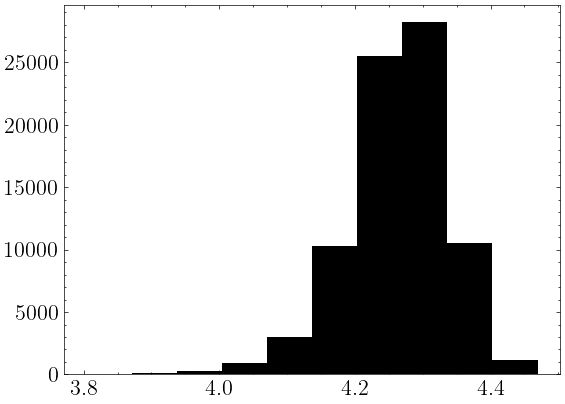

In [69]:
plt.hist(z_104_c4H_PIE_logT)

In [70]:
get_quantiles(z_104_c4H_PIE_logT)

4.27 -0.07 0.06


(array([   48.,   227.,   573.,  2670.,  8567., 19919., 27569., 16378.,
         3837.,   212.]),
 array([-0.12161255,  0.0421562 ,  0.20592495,  0.3696937 ,  0.53346245,
         0.6972312 ,  0.86099995,  1.0247687 ,  1.18853744,  1.35230619,
         1.51607494]),
 <BarContainer object of 10 artists>)

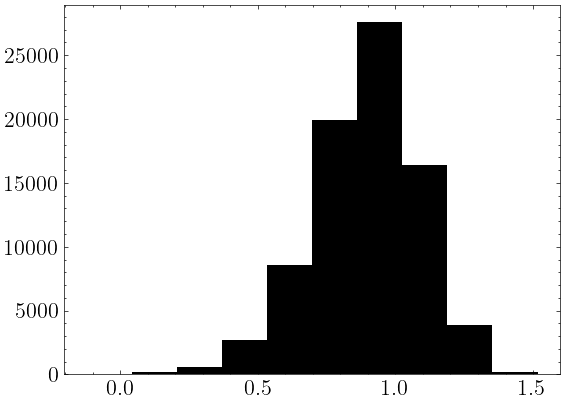

In [71]:
plt.hist(z_104_c4H_PIE_logt_rec)

In [72]:
get_quantiles(z_104_c4H_PIE_logt_rec)

0.91 -0.2 0.18


(array([1.0000e+01, 4.2000e+01, 1.6500e+02, 7.1500e+02, 3.4780e+03,
        1.3357e+04, 3.0479e+04, 2.2259e+04, 7.0290e+03, 2.4660e+03]),
 array([0.41119797, 0.46224228, 0.5132866 , 0.56433092, 0.61537524,
        0.66641956, 0.71746387, 0.76850819, 0.81955251, 0.87059683,
        0.92164115]),
 <BarContainer object of 10 artists>)

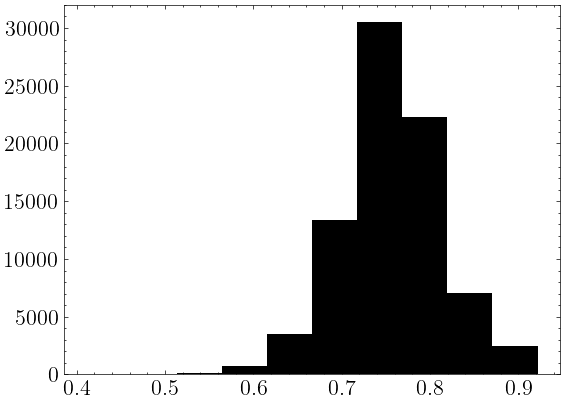

In [73]:
plt.hist(z_104_c4H_PIE_logt_cool-z_104_c4H_PIE_logt_rec)

In [74]:
get_quantiles(z_104_c4H_PIE_logt_cool-z_104_c4H_PIE_logt_rec)

0.75 -0.05 0.05


### c4L

In [75]:
z_104_c4L_PIE_logT, z_104_c4L_PIE_logt_rec, z_104_c4L_PIE_logt_cool = get_cooling_dist(z_104_c4_PIE_samples['log_hdens_p2'],
                                                                                             z_104_c4_PIE_samples['log_metals_p2'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([   80.,   690.,  2056.,  4307., 11038., 20183., 24035., 13128.,
         4019.,   464.]),
 array([3.75305137, 3.84291768, 3.932784  , 4.02265031, 4.11251662,
        4.20238293, 4.29224924, 4.38211555, 4.47198186, 4.56184818,
        4.65171449]),
 <BarContainer object of 10 artists>)

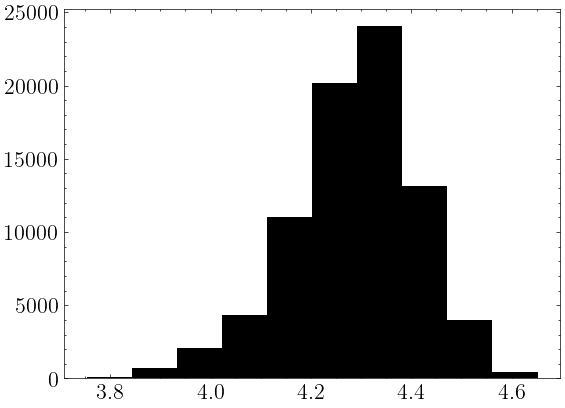

In [76]:
plt.hist(z_104_c4L_PIE_logT)

In [77]:
get_quantiles(z_104_c4L_PIE_logT)

4.3 -0.14 0.11


(array([  150.,  2630., 12775., 23232., 19824., 12609.,  5623.,  2260.,
          757.,   140.]),
 array([0.91660722, 1.08786453, 1.25912185, 1.43037916, 1.60163648,
        1.77289379, 1.94415111, 2.11540842, 2.28666573, 2.45792305,
        2.62918036]),
 <BarContainer object of 10 artists>)

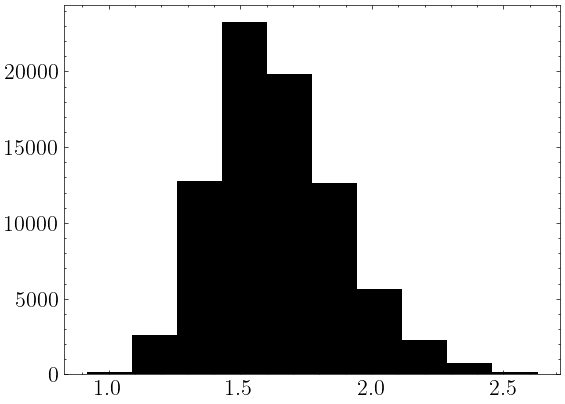

In [78]:
plt.hist(z_104_c4L_PIE_logt_rec)

In [79]:
get_quantiles(z_104_c4L_PIE_logt_rec)

1.61 -0.21 0.27


(array([  252.,   457.,   515.,   941.,  3006.,  8116., 19156., 30330.,
        15339.,  1888.]),
 array([-0.38185243, -0.23778119, -0.09370995,  0.05036128,  0.19443252,
         0.33850376,  0.482575  ,  0.62664623,  0.77071747,  0.91478871,
         1.05885994]),
 <BarContainer object of 10 artists>)

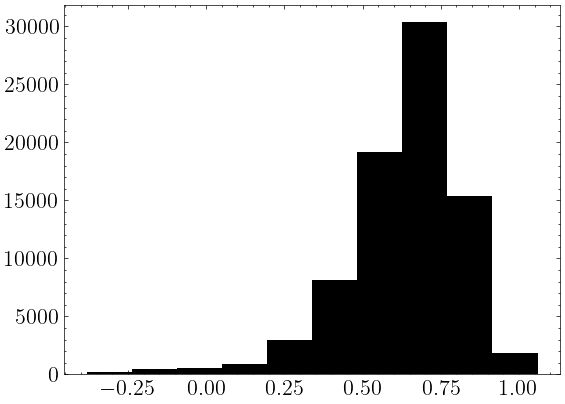

In [80]:
plt.hist(z_104_c4L_PIE_logt_cool-z_104_c4L_PIE_logt_rec)

In [81]:
get_quantiles(z_104_c4L_PIE_logt_cool-z_104_c4L_PIE_logt_rec)

0.66 -0.19 0.13


# z=1.09, PIE

## c1

In [82]:
z_109_c1_PIE_samples = pd.read_csv(loaddir+'z=1.09456549/cloudy_fits/two_phase.csv')

### c1H

In [83]:
z_109_c1H_PIE_logT, z_109_c1H_PIE_logt_rec, z_109_c1H_PIE_logt_cool = get_cooling_dist(z_109_c1_PIE_samples['log_hdens_p1'],
                                                                                       z_109_c1_PIE_samples['log_metals_p1'],
                                                                                       logq_rec_interp, logt_cool_interp)

(array([ 3787., 22644., 20449., 13221.,  8220.,  6150.,  3519.,  1386.,
          400.,   224.]),
 array([3.82303384, 3.85982351, 3.89661319, 3.93340286, 3.97019253,
        4.0069822 , 4.04377188, 4.08056155, 4.11735122, 4.1541409 ,
        4.19093057]),
 <BarContainer object of 10 artists>)

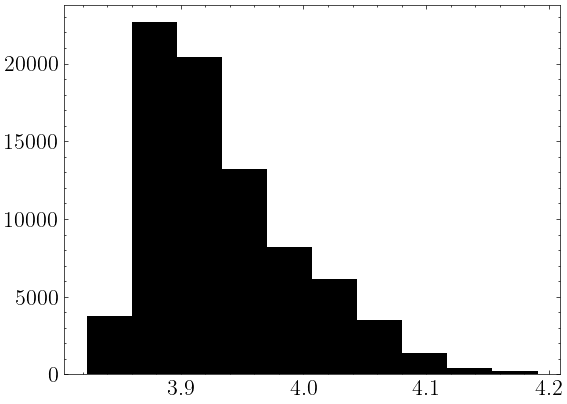

In [84]:
plt.hist(z_109_c1H_PIE_logT)

In [85]:
get_quantiles(z_109_c1H_PIE_logT), np.percentile(z_109_c1H_PIE_logT,100*cdf_3sig)

3.92 -0.04 0.08


(None, 4.167373250466889)

(array([  325.,  1523.,  4513., 10445., 18841., 24394., 13996.,  4825.,
         1052.,    86.]),
 array([0.54714759, 0.60517355, 0.66319952, 0.72122548, 0.77925145,
        0.83727742, 0.89530338, 0.95332935, 1.01135532, 1.06938128,
        1.12740725]),
 <BarContainer object of 10 artists>)

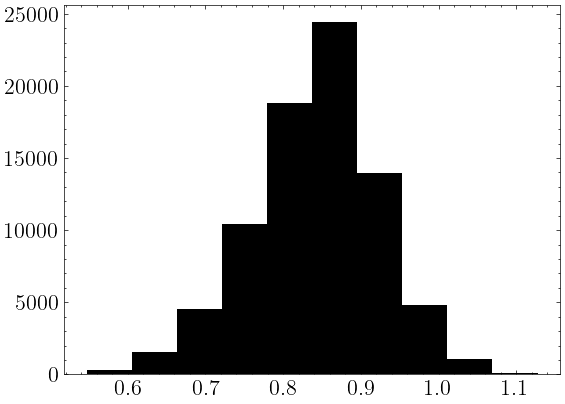

In [86]:
plt.hist(z_109_c1H_PIE_logt_rec)

In [87]:
get_quantiles(z_109_c1H_PIE_logt_rec)

0.85 -0.09 0.07


(array([  497., 11005., 23136., 17479., 12295.,  7910.,  4995.,  2032.,
          590.,    61.]),
 array([0.18685637, 0.23636563, 0.28587489, 0.33538416, 0.38489342,
        0.43440268, 0.48391194, 0.53342121, 0.58293047, 0.63243973,
        0.68194899]),
 <BarContainer object of 10 artists>)

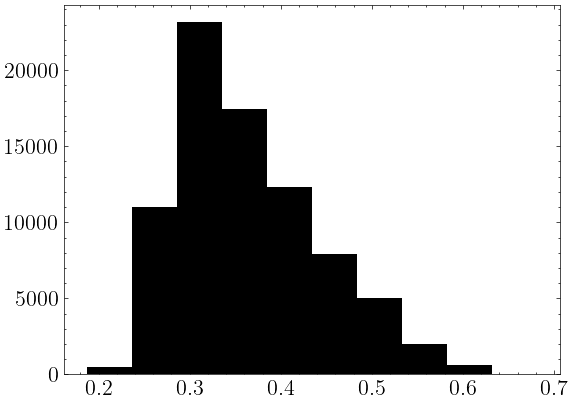

In [88]:
plt.hist(z_109_c1H_PIE_logt_cool-z_109_c1H_PIE_logt_rec)

In [89]:
get_quantiles(z_109_c1H_PIE_logt_cool-z_109_c1H_PIE_logt_rec)

0.35 -0.06 0.1


### c1L

In [90]:
z_109_c1L_PIE_logT, z_109_c1L_PIE_logt_rec, z_109_c1L_PIE_logt_cool = get_cooling_dist(z_109_c1_PIE_samples['log_hdens_p2'],
                                                                                       z_109_c1_PIE_samples['log_metals_p2'],
                                                                                       logq_rec_interp, logt_cool_interp)

(array([ 1632., 11147., 25564., 26731.,  5411.,  4199.,  3298.,  1572.,
          355.,    91.]),
 array([3.75814921, 3.83491229, 3.91167537, 3.98843845, 4.06520153,
        4.14196461, 4.21872769, 4.29549078, 4.37225386, 4.44901694,
        4.52578002]),
 <BarContainer object of 10 artists>)

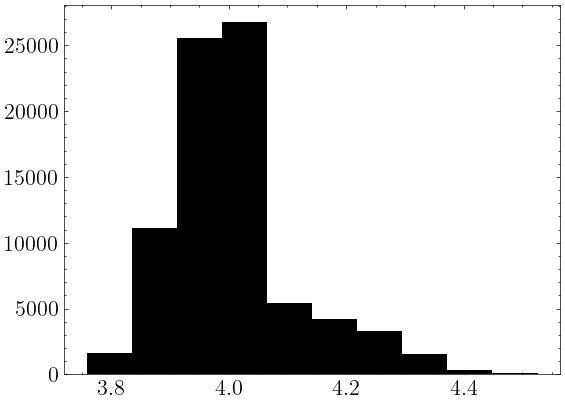

In [91]:
plt.hist(z_109_c1L_PIE_logT)

In [92]:
get_quantiles(z_109_c1L_PIE_logT), np.percentile(z_109_c1L_PIE_logT,100*cdf_3sig)

3.99 -0.08 0.1


(None, 4.443471519520604)

(array([2.1800e+03, 1.7186e+04, 3.1383e+04, 2.0048e+04, 6.3800e+03,
        2.0450e+03, 6.3000e+02, 8.8000e+01, 5.3000e+01, 7.0000e+00]),
 array([1.21126209, 1.33783494, 1.46440779, 1.59098063, 1.71755348,
        1.84412633, 1.97069918, 2.09727202, 2.22384487, 2.35041772,
        2.47699057]),
 <BarContainer object of 10 artists>)

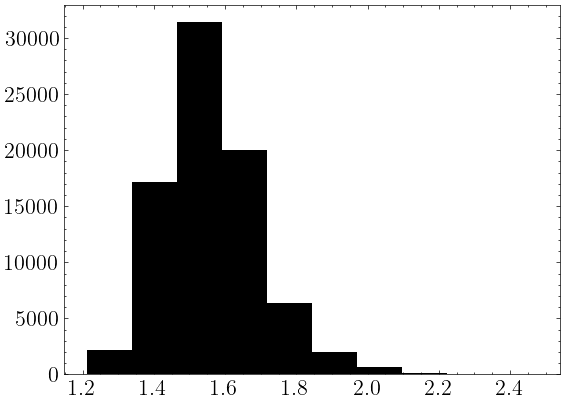

In [93]:
plt.hist(z_109_c1L_PIE_logt_rec)

In [94]:
get_quantiles(z_109_c1L_PIE_logt_rec)

1.55 -0.12 0.13


(array([ 4863., 12579., 19734., 18399.,  9562.,  5835.,  4515.,  3199.,
         1138.,   176.]),
 array([-0.48421779, -0.34309467, -0.20197155, -0.06084842,  0.0802747 ,
         0.22139783,  0.36252095,  0.50364407,  0.6447672 ,  0.78589032,
         0.92701344]),
 <BarContainer object of 10 artists>)

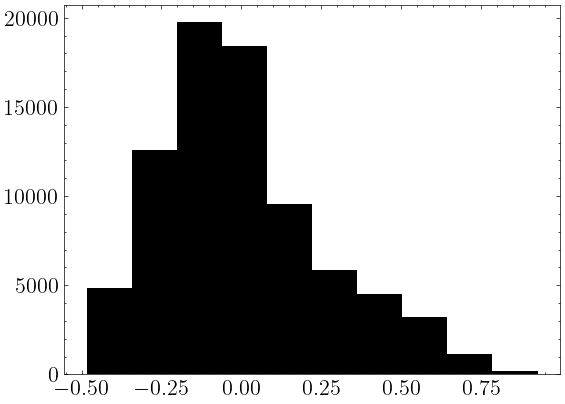

In [95]:
plt.hist(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_rec)

In [96]:
get_quantiles(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_rec)

-0.04 -0.2 0.31


# z=1.16, PIE

## c1

In [97]:
z_116_c1_PIE_samples = pd.read_csv(loaddir+'z=1.16590953/cloudy_fits/one_phase_c1.csv')

In [98]:
z_116_c1_PIE_logT, z_116_c1_PIE_logt_rec, z_116_c1_PIE_logt_cool = get_cooling_dist(z_116_c1_PIE_samples['log_hdens'],
                                                                                    z_116_c1_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([2.3000e+01, 5.0400e+02, 2.8880e+03, 1.0455e+04, 2.0485e+04,
        2.3294e+04, 1.5388e+04, 5.7820e+03, 1.0680e+03, 1.1300e+02]),
 array([4.41071325, 4.41688824, 4.42306322, 4.42923821, 4.43541319,
        4.44158818, 4.44776316, 4.45393814, 4.46011313, 4.46628811,
        4.4724631 ]),
 <BarContainer object of 10 artists>)

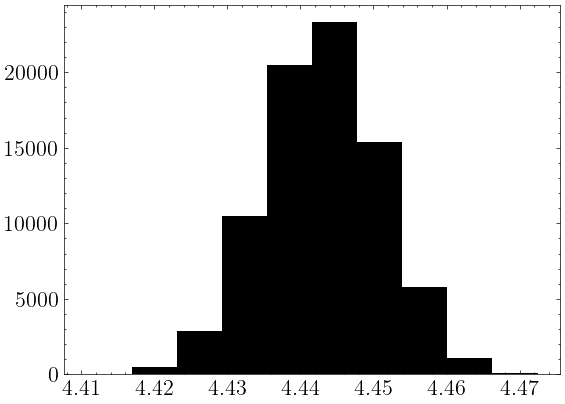

In [99]:
plt.hist(z_116_c1_PIE_logT)

In [100]:
get_quantiles(z_116_c1_PIE_logT)

4.44 -0.01 0.01


(array([   46.,   677.,  3704., 11253., 20431., 22814., 14627.,  5374.,
          967.,   107.]),
 array([1.13665301, 1.16541259, 1.19417218, 1.22293176, 1.25169135,
        1.28045093, 1.30921052, 1.3379701 , 1.36672969, 1.39548927,
        1.42424886]),
 <BarContainer object of 10 artists>)

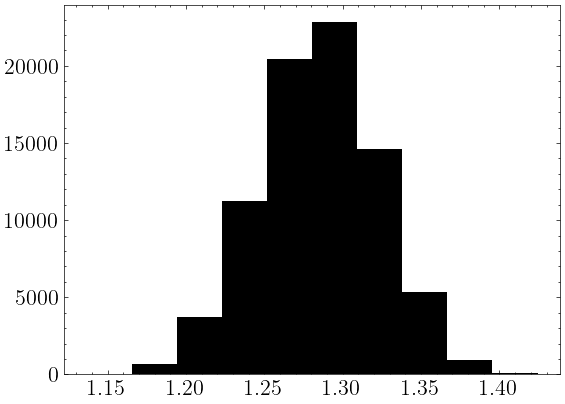

In [101]:
plt.hist(z_116_c1_PIE_logt_rec)

In [102]:
get_quantiles(z_116_c1_PIE_logt_rec)

1.29 -0.04 0.04


(array([   41.,   542.,  3802., 14185., 24421., 21922., 11441.,  3049.,
          535.,    62.]),
 array([0.88409219, 0.88788924, 0.8916863 , 0.89548336, 0.89928042,
        0.90307748, 0.90687454, 0.9106716 , 0.91446865, 0.91826571,
        0.92206277]),
 <BarContainer object of 10 artists>)

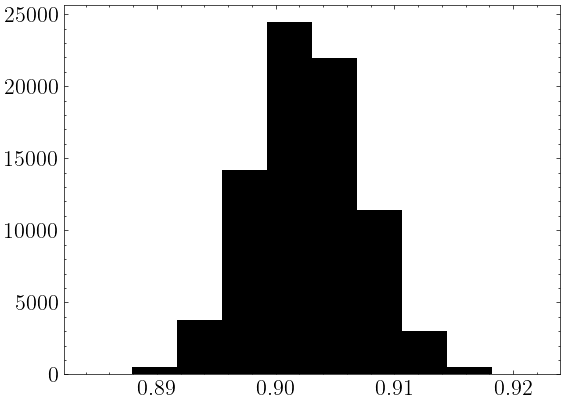

In [103]:
plt.hist(z_116_c1_PIE_logt_cool-z_116_c1_PIE_logt_rec)

In [104]:
get_quantiles(z_116_c1_PIE_logt_cool-z_116_c1_PIE_logt_rec)

0.9 -0.0 0.0


In [105]:
np.median(z_116_c1_PIE_logt_cool-z_116_c1_PIE_logt_rec)

0.9026380980130169

In [107]:
np.percentile(z_116_c1_PIE_logt_cool-z_116_c1_PIE_logt_rec,100*cdf_1sig)

0.9074114888201384

## c2

In [108]:
z_116_c2_PIE_samples = pd.read_csv(loaddir+'z=1.16590953/cloudy_fits/one_phase_c2.csv')

In [109]:
z_116_c2_PIE_logT, z_116_c2_PIE_logt_rec, z_116_c2_PIE_logt_cool = get_cooling_dist(z_116_c2_PIE_samples['log_hdens'],
                                                                                    z_116_c2_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([2.4000e+01, 1.9500e+02, 1.1300e+03, 5.0330e+03, 1.5233e+04,
        2.4208e+04, 2.3814e+04, 8.9300e+03, 1.3830e+03, 5.0000e+01]),
 array([4.41637232, 4.44598339, 4.47559446, 4.50520554, 4.53481661,
        4.56442768, 4.59403876, 4.62364983, 4.65326091, 4.68287198,
        4.71248305]),
 <BarContainer object of 10 artists>)

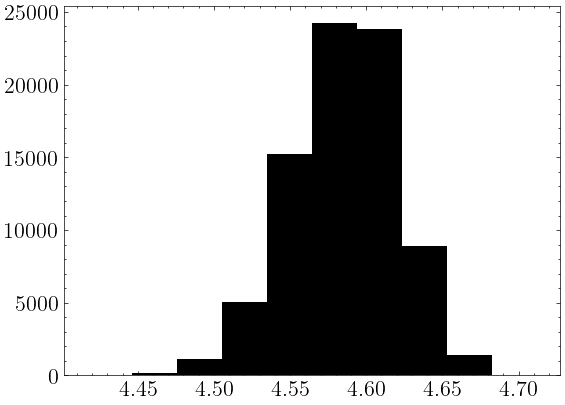

In [110]:
plt.hist(z_116_c2_PIE_logT)

In [111]:
get_quantiles(z_116_c2_PIE_logT)

4.59 -0.04 0.03


(array([8.5000e+01, 9.7700e+02, 5.4290e+03, 1.6329e+04, 2.5443e+04,
        2.0641e+04, 8.6540e+03, 2.1520e+03, 2.7900e+02, 1.1000e+01]),
 array([1.6229106 , 1.73649212, 1.85007365, 1.96365517, 2.07723669,
        2.19081822, 2.30439974, 2.41798126, 2.53156279, 2.64514431,
        2.75872583]),
 <BarContainer object of 10 artists>)

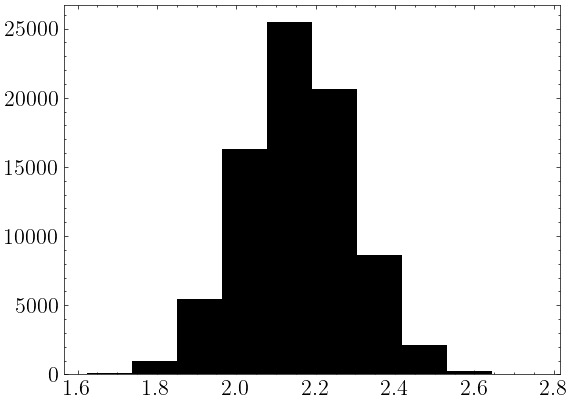

In [112]:
plt.hist(z_116_c2_PIE_logt_rec)

In [113]:
get_quantiles(z_116_c2_PIE_logt_rec)

2.15 -0.14 0.14


(array([2.0000e+01, 1.8100e+02, 9.4700e+02, 4.0620e+03, 1.3239e+04,
        2.2912e+04, 2.5616e+04, 1.1199e+04, 1.7660e+03, 5.8000e+01]),
 array([0.8316801 , 0.86053191, 0.88938372, 0.91823552, 0.94708733,
        0.97593914, 1.00479095, 1.03364275, 1.06249456, 1.09134637,
        1.12019818]),
 <BarContainer object of 10 artists>)

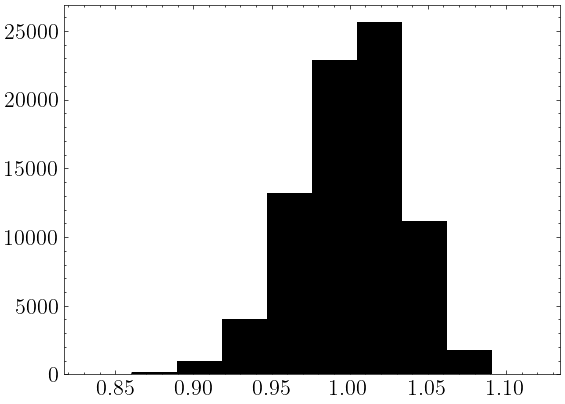

In [114]:
plt.hist(z_116_c2_PIE_logt_cool-z_116_c2_PIE_logt_rec)

In [115]:
get_quantiles(z_116_c2_PIE_logt_cool-z_116_c2_PIE_logt_rec)

1.0 -0.04 0.03


## c2

In [116]:
z_116_c2_PIE_samples = pd.read_csv(loaddir+'z=1.16590953/cloudy_fits/two_phase_c2.csv')

### c2H

In [117]:
z_116_c2H_PIE_logT, z_116_c2H_PIE_logt_rec, z_116_c2H_PIE_logt_cool = get_cooling_dist(z_116_c2_PIE_samples['log_hdens_p1'],
                                                                                             z_116_c2_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([8.0000e+00, 6.3000e+01, 6.3500e+02, 2.9960e+03, 9.5090e+03,
        2.0246e+04, 2.3050e+04, 1.6067e+04, 6.4410e+03, 9.8500e+02]),
 array([4.32137665, 4.35443962, 4.38750259, 4.42056556, 4.45362853,
        4.48669151, 4.51975448, 4.55281745, 4.58588042, 4.61894339,
        4.65200636]),
 <BarContainer object of 10 artists>)

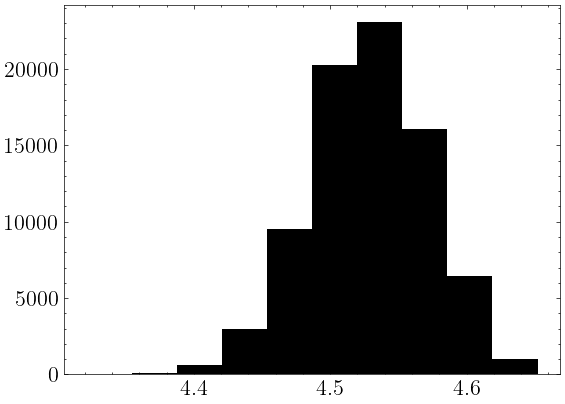

In [118]:
plt.hist(z_116_c2H_PIE_logT)

In [119]:
get_quantiles(z_116_c2H_PIE_logT)

4.53 -0.04 0.04


(array([   72.,   596.,  2270.,  7560., 14822., 18942., 16520., 11523.,
         6050.,  1645.]),
 array([1.00590988, 1.13537671, 1.26484354, 1.39431037, 1.52377721,
        1.65324404, 1.78271087, 1.9121777 , 2.04164453, 2.17111136,
        2.30057819]),
 <BarContainer object of 10 artists>)

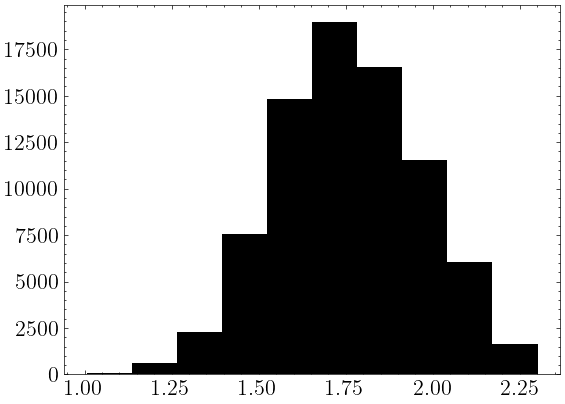

In [121]:
plt.hist(z_116_c2H_PIE_logt_rec)

In [122]:
get_quantiles(z_116_c2H_PIE_logt_rec)

1.75 -0.2 0.23


(array([5.0000e+00, 7.6000e+01, 7.6100e+02, 3.3950e+03, 1.0214e+04,
        2.1934e+04, 2.3455e+04, 1.4609e+04, 4.7780e+03, 7.7300e+02]),
 array([0.77935606, 0.80905494, 0.83875382, 0.8684527 , 0.89815158,
        0.92785046, 0.95754933, 0.98724821, 1.01694709, 1.04664597,
        1.07634485]),
 <BarContainer object of 10 artists>)

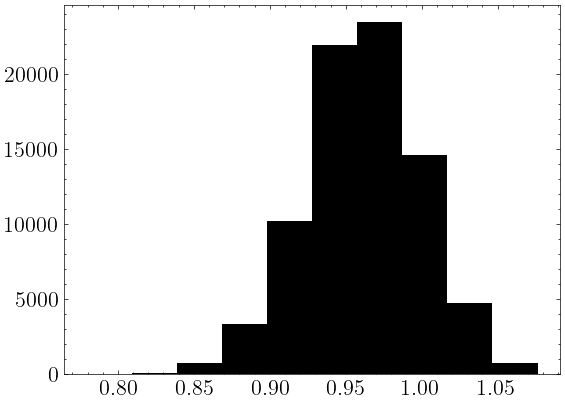

In [123]:
plt.hist(z_116_c2H_PIE_logt_cool-z_116_c2H_PIE_logt_rec)

In [124]:
get_quantiles(z_116_c2H_PIE_logt_cool-z_116_c2H_PIE_logt_rec)

0.96 -0.04 0.04


### c2L

In [125]:
z_116_c2L_PIE_logT, z_116_c2L_PIE_logt_rec, z_116_c2L_PIE_logt_cool = get_cooling_dist(z_116_c2_PIE_samples['log_hdens_p2'],
                                                                                             z_116_c2_PIE_samples['log_metals_p2'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([9.0000e+00, 2.5000e+01, 1.8000e+02, 7.6500e+02, 3.7980e+03,
        9.7690e+03, 1.9858e+04, 2.9708e+04, 1.4386e+04, 1.5020e+03]),
 array([4.16761311, 4.22517909, 4.28274507, 4.34031106, 4.39787704,
        4.45544302, 4.51300901, 4.57057499, 4.62814097, 4.68570696,
        4.74327294]),
 <BarContainer object of 10 artists>)

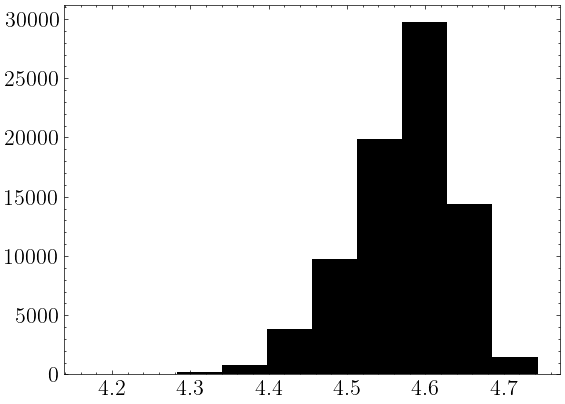

In [126]:
plt.hist(z_116_c2L_PIE_logT)

In [127]:
get_quantiles(z_116_c2L_PIE_logT)

4.58 -0.08 0.05


(array([  164.,  4179., 16694., 27333., 17384.,  7184.,  3402.,  2175.,
         1172.,   313.]),
 array([1.68065262, 1.84307754, 2.00550246, 2.16792738, 2.33035229,
        2.49277721, 2.65520213, 2.81762705, 2.98005197, 3.14247689,
        3.30490181]),
 <BarContainer object of 10 artists>)

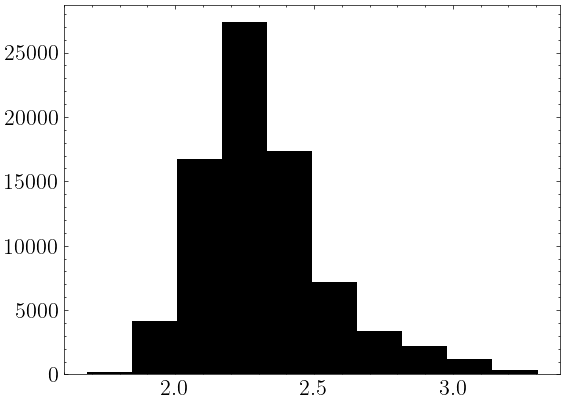

In [128]:
plt.hist(z_116_c2L_PIE_logt_rec)

In [129]:
get_quantiles(z_116_c2L_PIE_logt_rec)

2.28 -0.18 0.24


(array([1.0000e+00, 8.0000e+00, 2.8000e+01, 1.3900e+02, 3.0900e+02,
        1.2420e+03, 3.6970e+03, 1.4777e+04, 4.2101e+04, 1.7698e+04]),
 array([-0.04188175,  0.07693524,  0.19575223,  0.31456922,  0.43338621,
         0.5522032 ,  0.67102019,  0.78983718,  0.90865417,  1.02747115,
         1.14628814]),
 <BarContainer object of 10 artists>)

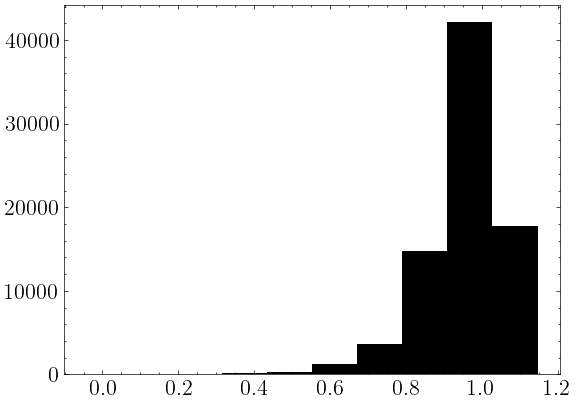

In [130]:
plt.hist(z_116_c2L_PIE_logt_cool-z_116_c2L_PIE_logt_rec)

In [131]:
get_quantiles(z_116_c2L_PIE_logt_cool-z_116_c2L_PIE_logt_rec)

0.98 -0.11 0.06


# z=1.22, PIE

## c1

In [144]:
z_122_c1_PIE_samples = pd.read_csv(loaddir+'z=1.22541394/cloudy_fits/one_phase.csv')

In [145]:
z_122_c1_PIE_logT, z_122_c1_PIE_logt_rec, z_122_c1_PIE_logt_cool = get_cooling_dist(z_122_c1_PIE_samples['log_hdens'],
                                                                                    z_122_c1_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([3.0000e+00, 4.9000e+01, 3.3200e+02, 2.5930e+03, 1.1501e+04,
        2.8373e+04, 2.6431e+04, 9.2800e+03, 1.3540e+03, 8.4000e+01]),
 array([4.44534055, 4.45702811, 4.46871567, 4.48040324, 4.4920908 ,
        4.50377836, 4.51546592, 4.52715348, 4.53884105, 4.55052861,
        4.56221617]),
 <BarContainer object of 10 artists>)

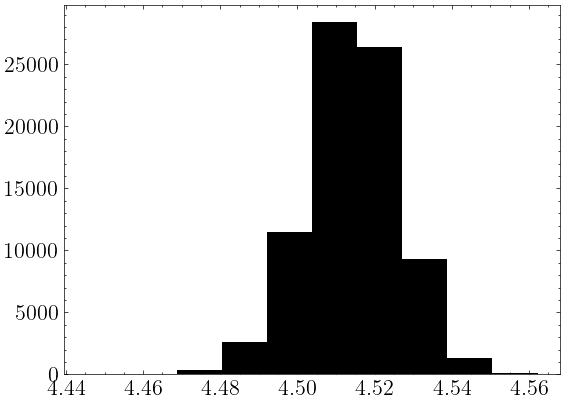

In [146]:
plt.hist(z_122_c1_PIE_logT)

In [147]:
get_quantiles(z_122_c1_PIE_logT)

4.51 -0.01 0.01


(array([4.0000e+00, 8.0000e+01, 9.5000e+02, 7.0080e+03, 2.2692e+04,
        3.1378e+04, 1.4594e+04, 3.0650e+03, 2.2000e+02, 9.0000e+00]),
 array([2.19208865, 2.23977302, 2.28745738, 2.33514174, 2.38282611,
        2.43051047, 2.47819483, 2.5258792 , 2.57356356, 2.62124792,
        2.66893228]),
 <BarContainer object of 10 artists>)

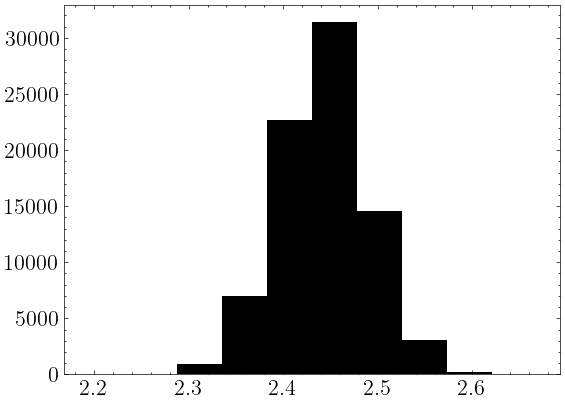

In [148]:
plt.hist(z_122_c1_PIE_logt_rec)

In [149]:
get_quantiles(z_122_c1_PIE_logt_rec)

2.44 -0.05 0.05


(array([3.1000e+01, 2.6100e+02, 1.5310e+03, 8.0610e+03, 2.3477e+04,
        2.8836e+04, 1.4466e+04, 3.0710e+03, 2.4900e+02, 1.7000e+01]),
 array([0.77628841, 0.78870577, 0.80112314, 0.8135405 , 0.82595786,
        0.83837522, 0.85079258, 0.86320994, 0.8756273 , 0.88804466,
        0.90046202]),
 <BarContainer object of 10 artists>)

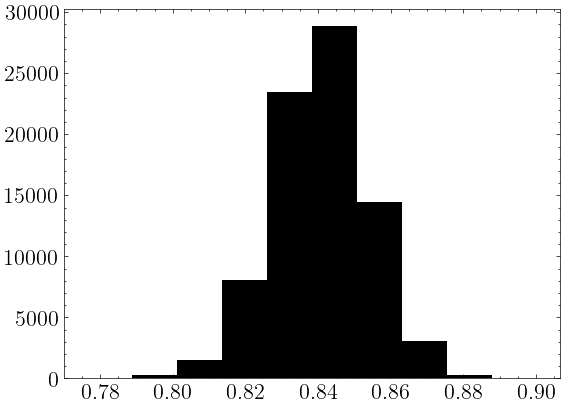

In [150]:
plt.hist(z_122_c1_PIE_logt_cool-z_122_c1_PIE_logt_rec)

In [151]:
get_quantiles(z_122_c1_PIE_logt_cool-z_122_c1_PIE_logt_rec)

0.84 -0.01 0.01


## c1

In [152]:
z_122_c1_PIE_samples = pd.read_csv(loaddir+'z=1.22541394/cloudy_fits/two_phase.csv')

### c1H

In [153]:
z_122_c1H_PIE_logT, z_122_c1H_PIE_logt_rec, z_122_c1H_PIE_logt_cool = get_cooling_dist(z_122_c1_PIE_samples['log_hdens_p1'],
                                                                                             z_122_c1_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([   47.,   195.,   454.,   991.,  2944.,  8105., 16568., 24698.,
        23336.,  2662.]),
 array([3.65889587, 3.75947334, 3.86005081, 3.96062829, 4.06120576,
        4.16178324, 4.26236071, 4.36293819, 4.46351566, 4.56409314,
        4.66467061]),
 <BarContainer object of 10 artists>)

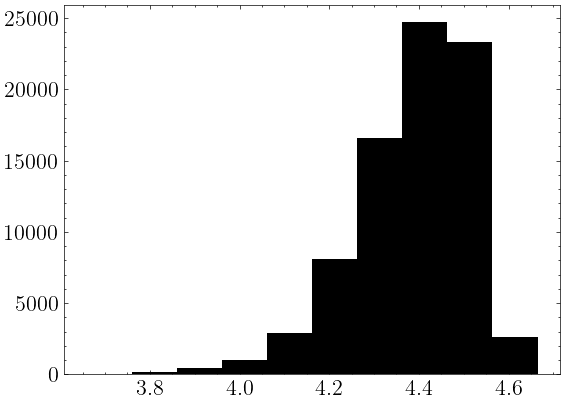

In [154]:
plt.hist(z_122_c1H_PIE_logT)

In [155]:
get_quantiles(z_122_c1H_PIE_logT)

4.41 -0.15 0.1


(array([  133.,    42.,   204.,   831.,  2669.,  9700., 21753., 26058.,
        15055.,  3555.]),
 array([-1.22226039, -0.84990251, -0.47754463, -0.10518675,  0.26717112,
         0.639529  ,  1.01188688,  1.38424476,  1.75660264,  2.12896052,
         2.5013184 ]),
 <BarContainer object of 10 artists>)

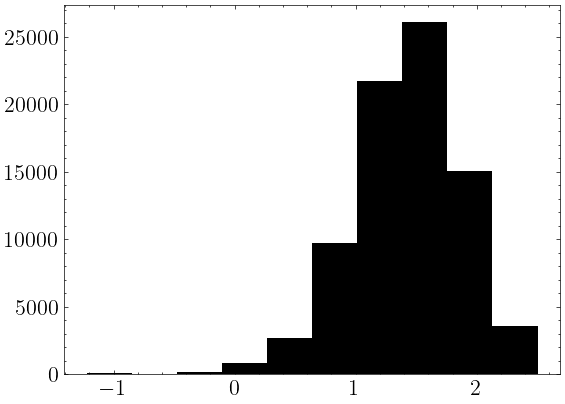

In [156]:
plt.hist(z_122_c1H_PIE_logt_rec)

In [157]:
get_quantiles(z_122_c1H_PIE_logt_rec)

1.45 -0.45 0.42


(array([1.6000e+01, 2.0000e+00, 7.0000e+00, 1.6000e+01, 9.1000e+01,
        2.0200e+02, 2.7140e+03, 1.8878e+04, 4.5020e+04, 1.3054e+04]),
 array([-0.46177268, -0.30704509, -0.1523175 ,  0.00241008,  0.15713767,
         0.31186526,  0.46659285,  0.62132043,  0.77604802,  0.93077561,
         1.08550319]),
 <BarContainer object of 10 artists>)

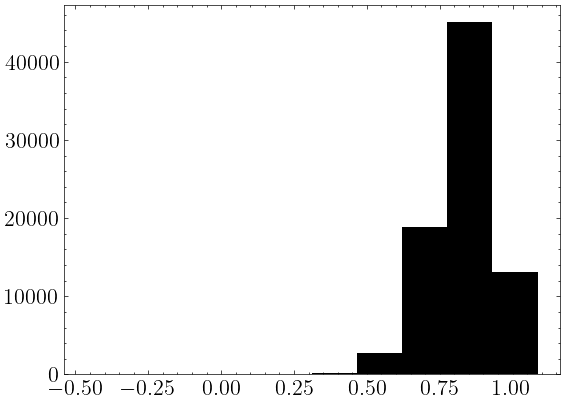

In [158]:
plt.hist(z_122_c1H_PIE_logt_cool-z_122_c1H_PIE_logt_rec)

In [159]:
get_quantiles(z_122_c1H_PIE_logt_cool-z_122_c1H_PIE_logt_rec)

0.84 -0.12 0.09


### c1L

In [160]:
z_122_c1L_PIE_logT, z_122_c1L_PIE_logt_rec, z_122_c1L_PIE_logt_cool = get_cooling_dist(z_122_c1_PIE_samples['log_hdens_p2'],
                                                                                             z_122_c1_PIE_samples['log_metals_p2'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([  121.,  4017., 15898., 25222., 18919.,  9002.,  3432.,  1889.,
         1003.,   497.]),
 array([4.18307475, 4.23681086, 4.29054697, 4.34428308, 4.39801919,
        4.4517553 , 4.50549141, 4.55922752, 4.61296363, 4.66669974,
        4.72043585]),
 <BarContainer object of 10 artists>)

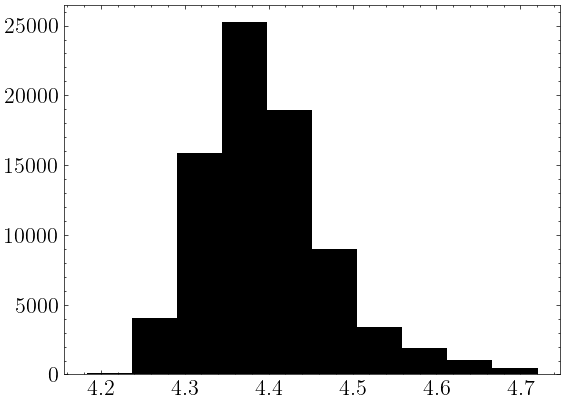

In [161]:
plt.hist(z_122_c1L_PIE_logT)

In [162]:
get_quantiles(z_122_c1L_PIE_logT)

4.39 -0.06 0.08


(array([ 1556., 23045., 29256., 14659.,  5561.,  2402.,  1305.,   934.,
          850.,   432.]),
 array([2.10286292, 2.22172977, 2.34059662, 2.45946348, 2.57833033,
        2.69719718, 2.81606404, 2.93493089, 3.05379774, 3.17266459,
        3.29153145]),
 <BarContainer object of 10 artists>)

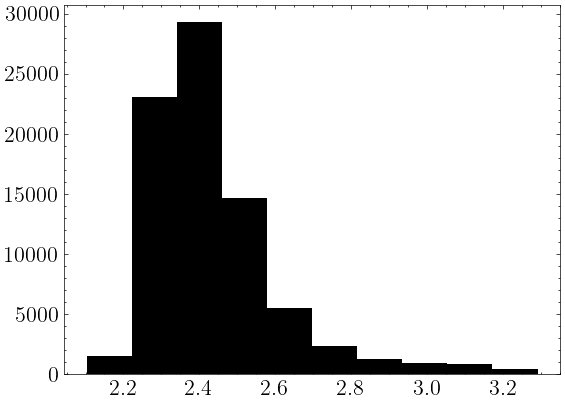

In [164]:
plt.hist(z_122_c1L_PIE_logt_rec)

In [165]:
get_quantiles(z_122_c1L_PIE_logt_rec)

2.4 -0.1 0.17


(array([ 1533.,  2613.,  4421.,  6064.,  9221., 14100., 17443., 15207.,
         8328.,  1070.]),
 array([-0.40655105, -0.27275085, -0.13895065, -0.00515045,  0.12864975,
         0.26244995,  0.39625016,  0.53005036,  0.66385056,  0.79765076,
         0.93145096]),
 <BarContainer object of 10 artists>)

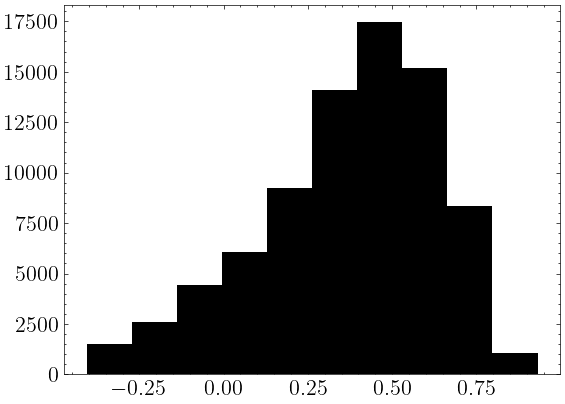

In [166]:
plt.hist(z_122_c1L_PIE_logt_cool-z_122_c1L_PIE_logt_rec)

In [167]:
get_quantiles(z_122_c1L_PIE_logt_cool-z_122_c1L_PIE_logt_rec)

0.42 -0.32 0.22


# z=1.26, PIE

## c1

In [168]:
z_126_c1_PIE_samples = pd.read_csv(loaddir+'z=1.25937492/cloudy_fits/one_phase_c1.csv')

In [169]:
z_126_c1_PIE_logT, z_126_c1_PIE_logt_rec, z_126_c1_PIE_logt_cool = get_cooling_dist(z_126_c1_PIE_samples['log_hdens'],
                                                                                    z_126_c1_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([4.7090e+03, 1.0369e+04, 1.0799e+04, 9.8290e+03, 8.6330e+03,
        9.1360e+03, 2.6178e+04, 2.4400e+02, 8.0000e+01, 2.3000e+01]),
 array([3.64959434, 3.70570945, 3.76182455, 3.81793965, 3.87405476,
        3.93016986, 3.98628496, 4.04240007, 4.09851517, 4.15463027,
        4.21074537]),
 <BarContainer object of 10 artists>)

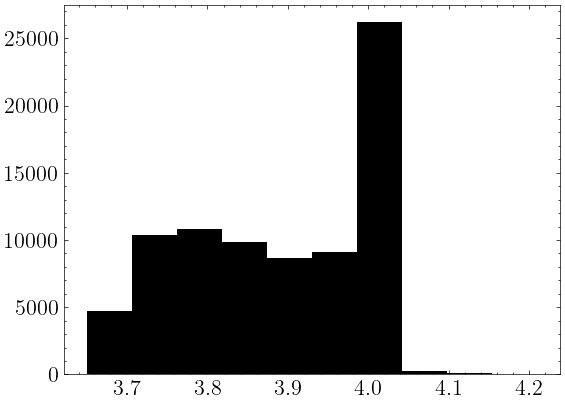

In [170]:
plt.hist(z_126_c1_PIE_logT)

In [171]:
get_quantiles(z_126_c1_PIE_logT), np.percentile(z_126_c1_PIE_logT, 100*cdf_3sig)

3.9 -0.15 0.1


(None, 4.095827272593515)

(array([9.2600e+02, 4.3450e+03, 1.0212e+04, 3.4735e+04, 1.9632e+04,
        6.8760e+03, 2.4400e+03, 6.9000e+02, 1.2900e+02, 1.5000e+01]),
 array([0.72999532, 0.81751554, 0.90503577, 0.99255599, 1.08007621,
        1.16759644, 1.25511666, 1.34263688, 1.43015711, 1.51767733,
        1.60519755]),
 <BarContainer object of 10 artists>)

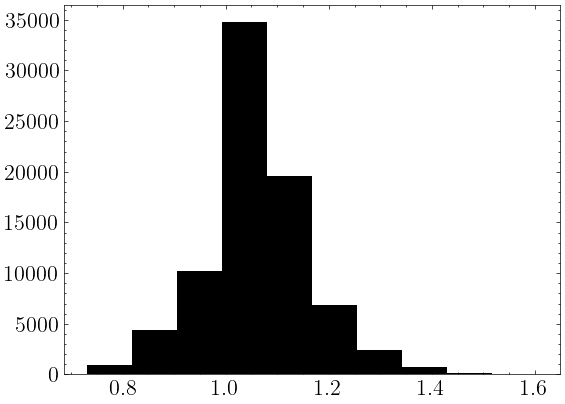

In [172]:
plt.hist(z_126_c1_PIE_logt_rec)

In [173]:
get_quantiles(z_126_c1_PIE_logt_rec)

1.06 -0.09 0.08


(array([  703.,  3516.,  8098., 24799., 28027.,  9708.,  3220.,  1441.,
          414.,    74.]),
 array([-0.45110817, -0.35373242, -0.25635666, -0.15898091, -0.06160515,
         0.0357706 ,  0.13314635,  0.23052211,  0.32789786,  0.42527362,
         0.52264937]),
 <BarContainer object of 10 artists>)

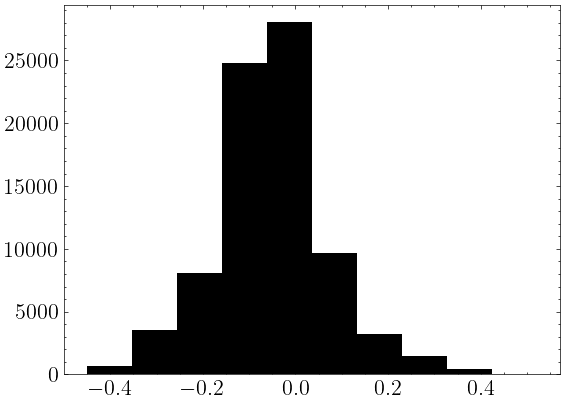

In [174]:
plt.hist(z_126_c1_PIE_logt_cool-z_126_c1_PIE_logt_rec)

In [175]:
get_quantiles(z_126_c1_PIE_logt_cool-z_126_c1_PIE_logt_rec)

-0.06 -0.1 0.1


# z=1.27, PIE

## c1

In [177]:
z_127_c1_PIE_samples = pd.read_csv(loaddir+'z=1.27767328/cloudy_fits/two_phase_c1.csv')

### c1L

In [178]:
z_127_c1L_PIE_logT, z_127_c1L_PIE_logt_rec, z_127_c1L_PIE_logt_cool = get_cooling_dist(z_127_c1_PIE_samples['log_hdens_p1'],
                                                                                       z_127_c1_PIE_samples['log_metals_p1'],
                                                                                       logq_rec_interp, logt_cool_interp)

(array([ 7548., 12606.,  9850., 10064.,  8197., 12060., 13087.,  6112.,
          460.,    16.]),
 array([3.7624699 , 3.8236216 , 3.8847733 , 3.94592499, 4.00707669,
        4.06822839, 4.12938009, 4.19053179, 4.25168349, 4.31283519,
        4.37398689]),
 <BarContainer object of 10 artists>)

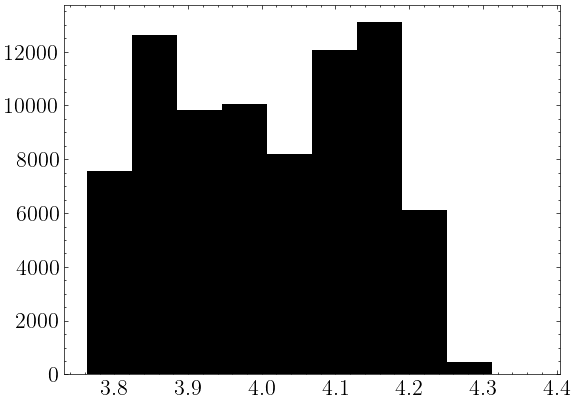

In [179]:
plt.hist(z_127_c1L_PIE_logT)

In [180]:
get_quantiles(z_127_c1L_PIE_logT)

4.01 -0.16 0.15


(array([  266.,  2346.,  9913., 14618., 11406., 10816.,  9957., 10859.,
         8998.,   821.]),
 array([-0.50061918, -0.28754965, -0.07448012,  0.13858942,  0.35165895,
         0.56472848,  0.77779802,  0.99086755,  1.20393708,  1.41700662,
         1.63007615]),
 <BarContainer object of 10 artists>)

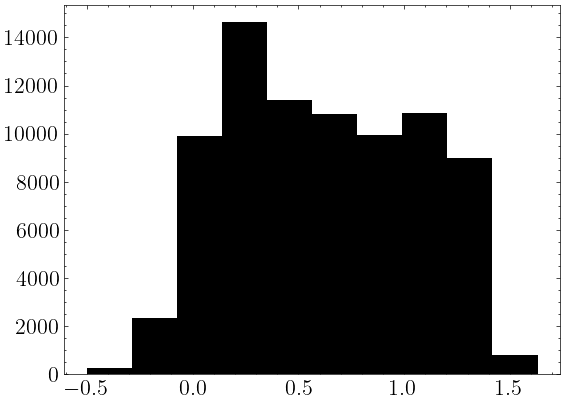

In [181]:
plt.hist(z_127_c1L_PIE_logt_rec)

In [182]:
get_quantiles(z_127_c1L_PIE_logt_rec)

0.59 -0.45 0.56


(array([  115.,   274.,   811.,  1403.,  3407.,  8510., 15810., 34267.,
        15124.,   279.]),
 array([-0.41467793, -0.28995465, -0.16523137, -0.04050809,  0.08421519,
         0.20893848,  0.33366176,  0.45838504,  0.58310832,  0.7078316 ,
         0.83255488]),
 <BarContainer object of 10 artists>)

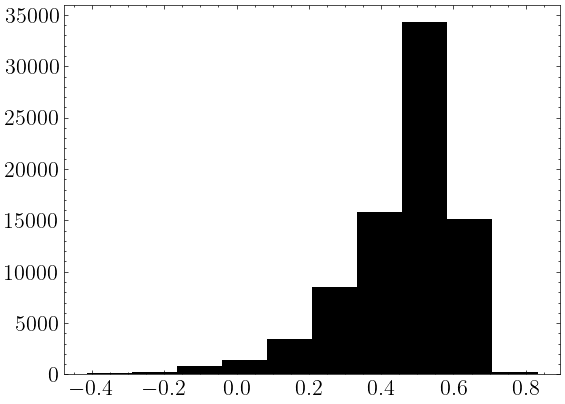

In [183]:
plt.hist(z_127_c1L_PIE_logt_cool-z_127_c1L_PIE_logt_rec)

In [184]:
get_quantiles(z_127_c1L_PIE_logt_cool-z_127_c1L_PIE_logt_rec)

0.51 -0.19 0.09


### c1H

In [185]:
z_127_c1H_PIE_logT, z_127_c1H_PIE_logt_rec, z_127_c1H_PIE_logt_cool = get_cooling_dist(z_127_c1_PIE_samples['log_hdens_p2'],
                                                                                       z_127_c1_PIE_samples['log_metals_p2'],
                                                                                       logq_rec_interp, logt_cool_interp)

(array([6.0000e+00, 7.5000e+01, 4.9900e+02, 2.9940e+03, 1.0035e+04,
        2.1129e+04, 2.6447e+04, 1.3711e+04, 4.4240e+03, 6.8000e+02]),
 array([3.97339449, 4.02108376, 4.06877302, 4.11646229, 4.16415156,
        4.21184082, 4.25953009, 4.30721935, 4.35490862, 4.40259788,
        4.45028715]),
 <BarContainer object of 10 artists>)

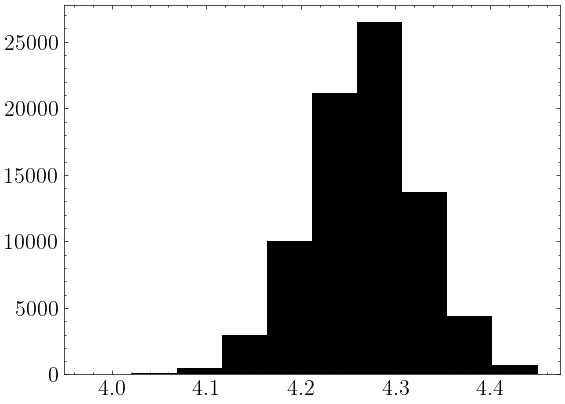

In [186]:
plt.hist(z_127_c1H_PIE_logT)

In [187]:
get_quantiles(z_127_c1H_PIE_logT)

4.27 -0.06 0.05


(array([   82.,   810.,  7481., 19563., 24695., 15148.,  7507.,  3285.,
         1292.,   137.]),
 array([1.82915306, 1.90986802, 1.99058298, 2.07129795, 2.15201291,
        2.23272787, 2.31344283, 2.39415779, 2.47487276, 2.55558772,
        2.63630268]),
 <BarContainer object of 10 artists>)

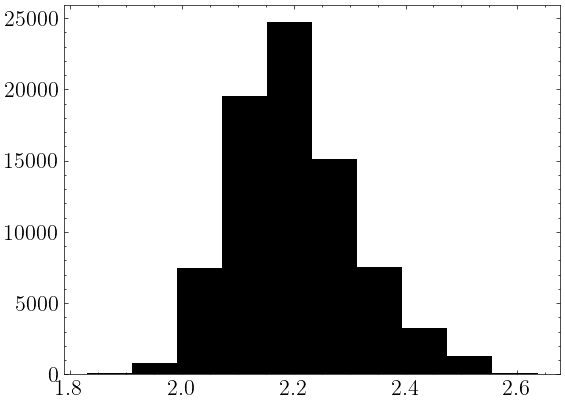

In [188]:
plt.hist(z_127_c1H_PIE_logt_rec)

In [189]:
get_quantiles(z_127_c1H_PIE_logt_rec)

2.19 -0.1 0.12


(array([ 3283.,  6179.,  9308., 13328., 14819., 14920., 10525.,  6212.,
         1334.,    92.]),
 array([-0.38438982, -0.28424718, -0.18410453, -0.08396189,  0.01618075,
         0.1163234 ,  0.21646604,  0.31660868,  0.41675133,  0.51689397,
         0.61703661]),
 <BarContainer object of 10 artists>)

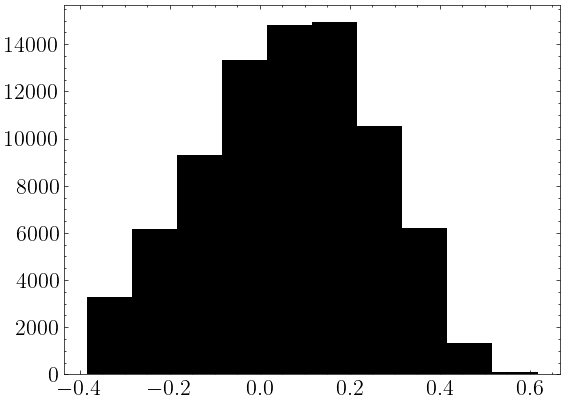

In [190]:
plt.hist(z_127_c1H_PIE_logt_cool-z_127_c1H_PIE_logt_rec)

In [191]:
get_quantiles(z_127_c1H_PIE_logt_cool-z_127_c1H_PIE_logt_rec)

0.07 -0.22 0.19


## c2

In [192]:
z_127_c2_PIE_samples = pd.read_csv(loaddir+'z=1.27767328/cloudy_fits/one_phase_c2.csv')

In [193]:
z_127_c2_PIE_logT, z_127_c2_PIE_logt_rec, z_127_c2_PIE_logt_cool = get_cooling_dist(z_127_c2_PIE_samples['log_hdens'],
                                                                                    z_127_c2_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([   38.,   195.,  1119.,  4986., 16274., 26467., 21267.,  8143.,
         1395.,   116.]),
 array([4.29161578, 4.30963124, 4.3276467 , 4.34566216, 4.36367763,
        4.38169309, 4.39970855, 4.41772401, 4.43573948, 4.45375494,
        4.4717704 ]),
 <BarContainer object of 10 artists>)

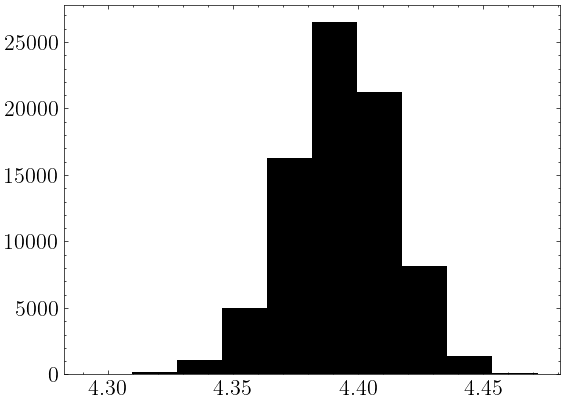

In [194]:
plt.hist(z_127_c2_PIE_logT)

In [195]:
get_quantiles(z_127_c2_PIE_logT)

4.39 -0.02 0.02


(array([   76.,   548.,  2984., 11684., 21817., 23673., 13851.,  4459.,
          839.,    69.]),
 array([1.8764294 , 1.92759044, 1.97875147, 2.02991251, 2.08107354,
        2.13223458, 2.18339561, 2.23455665, 2.28571768, 2.33687872,
        2.38803975]),
 <BarContainer object of 10 artists>)

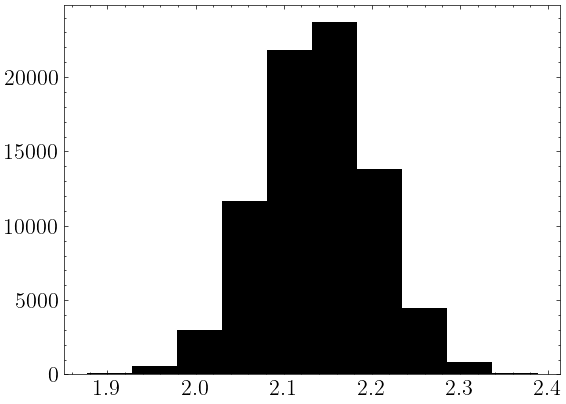

In [196]:
plt.hist(z_127_c2_PIE_logt_rec)

In [197]:
get_quantiles(z_127_c2_PIE_logt_rec)

2.14 -0.06 0.06


(array([   27.,   135.,  1012.,  5189., 16379., 25852., 21049.,  8835.,
         1417.,   105.]),
 array([0.56364492, 0.58505363, 0.60646234, 0.62787105, 0.64927976,
        0.67068847, 0.69209718, 0.71350589, 0.7349146 , 0.75632331,
        0.77773202]),
 <BarContainer object of 10 artists>)

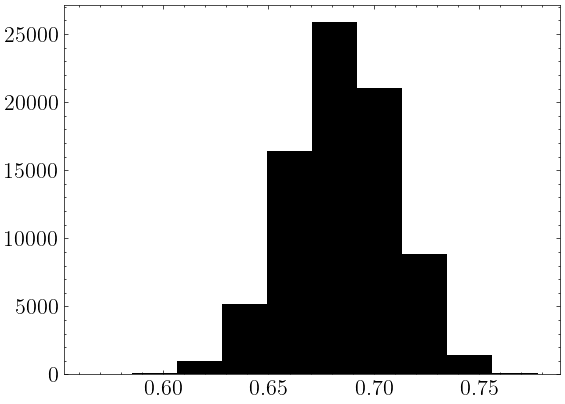

In [198]:
plt.hist(z_127_c2_PIE_logt_cool-z_127_c2_PIE_logt_rec)

In [199]:
get_quantiles(z_127_c2_PIE_logt_cool-z_127_c2_PIE_logt_rec)

0.69 -0.03 0.02


## c2

In [200]:
z_127_c2_PIE_samples = pd.read_csv(loaddir+'z=1.27767328/cloudy_fits/two_phase_c2.csv')

### c2H

In [201]:
z_127_c2H_PIE_logT, z_127_c2H_PIE_logt_rec, z_127_c2H_PIE_logt_cool = get_cooling_dist(z_127_c2_PIE_samples['log_hdens_p1'],
                                                                                             z_127_c2_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([  530.,   703.,  1421.,  2815.,  6168., 18327., 25285., 16788.,
         7314.,   649.]),
 array([3.76264243, 3.84704996, 3.9314575 , 4.01586504, 4.10027257,
        4.18468011, 4.26908765, 4.35349518, 4.43790272, 4.52231026,
        4.60671779]),
 <BarContainer object of 10 artists>)

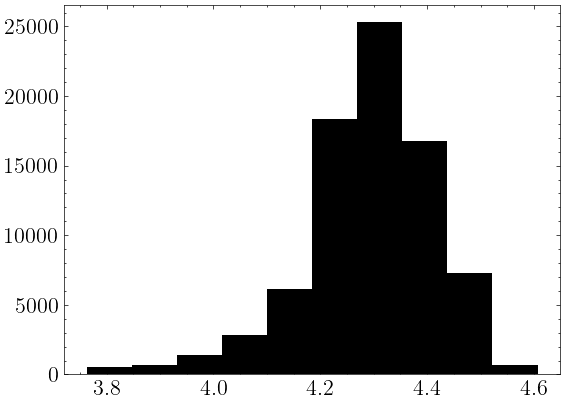

In [202]:
plt.hist(z_127_c2H_PIE_logT)

In [203]:
get_quantiles(z_127_c2H_PIE_logT)

4.3 -0.11 0.11


(array([ 4498., 11406., 12685., 12582., 11055.,  9401.,  9599.,  6949.,
         1700.,   125.]),
 array([-0.11746071,  0.10823984,  0.3339404 ,  0.55964095,  0.7853415 ,
         1.01104206,  1.23674261,  1.46244317,  1.68814372,  1.91384427,
         2.13954483]),
 <BarContainer object of 10 artists>)

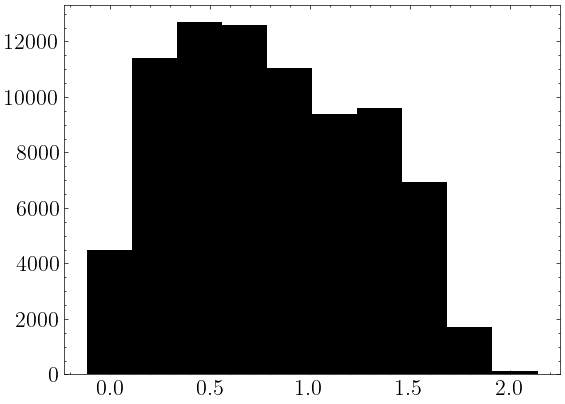

In [204]:
plt.hist(z_127_c2H_PIE_logt_rec)

In [205]:
get_quantiles(z_127_c2H_PIE_logt_rec)

0.76 -0.49 0.6


(array([1.9000e+01, 7.3000e+01, 1.2400e+02, 5.6000e+02, 1.6910e+03,
        5.7110e+03, 1.1494e+04, 2.1085e+04, 3.7835e+04, 1.4080e+03]),
 array([0.14846231, 0.2371472 , 0.32583209, 0.41451699, 0.50320188,
        0.59188677, 0.68057167, 0.76925656, 0.85794145, 0.94662635,
        1.03531124]),
 <BarContainer object of 10 artists>)

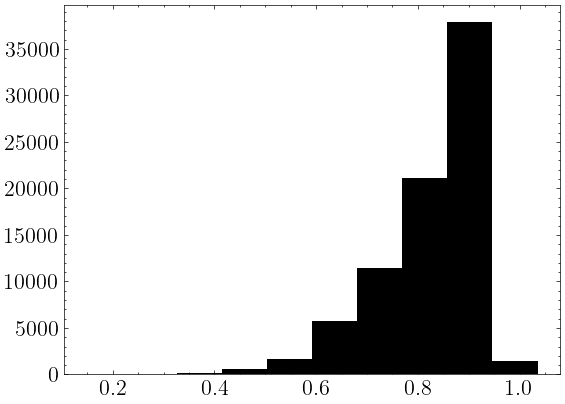

In [206]:
plt.hist(z_127_c2H_PIE_logt_cool-z_127_c2H_PIE_logt_rec)

In [208]:
get_quantiles(z_127_c2H_PIE_logt_cool-z_127_c2H_PIE_logt_rec)

0.86 -0.14 0.04


### c2L

In [209]:
z_127_c2L_PIE_logT, z_127_c2L_PIE_logt_rec, z_127_c2L_PIE_logt_cool = get_cooling_dist(z_127_c2_PIE_samples['log_hdens_p2'],
                                                                                             z_127_c2_PIE_samples['log_metals_p2'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([  168.,   950.,  4179., 11909., 19525., 22512., 15043.,  4680.,
          862.,   172.]),
 array([3.92701693, 3.98228546, 4.03755398, 4.09282251, 4.14809104,
        4.20335957, 4.25862809, 4.31389662, 4.36916515, 4.42443368,
        4.4797022 ]),
 <BarContainer object of 10 artists>)

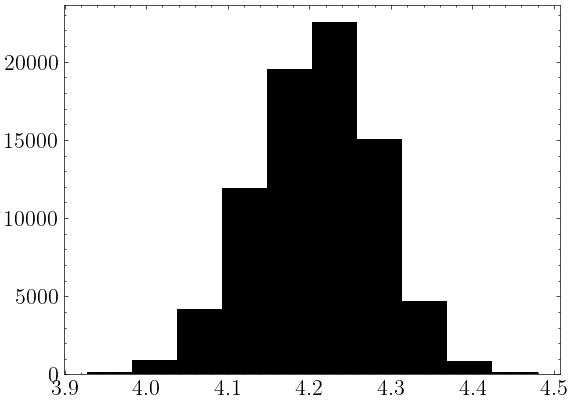

In [210]:
plt.hist(z_127_c2L_PIE_logT)

In [211]:
get_quantiles(z_127_c2L_PIE_logT)

4.21 -0.08 0.07


(array([  239.,  3397., 16318., 28781., 21385.,  7127.,  1931.,   497.,
          142.,   183.]),
 array([1.76728626, 1.83978319, 1.91228012, 1.98477704, 2.05727397,
        2.1297709 , 2.20226782, 2.27476475, 2.34726168, 2.4197586 ,
        2.49225553]),
 <BarContainer object of 10 artists>)

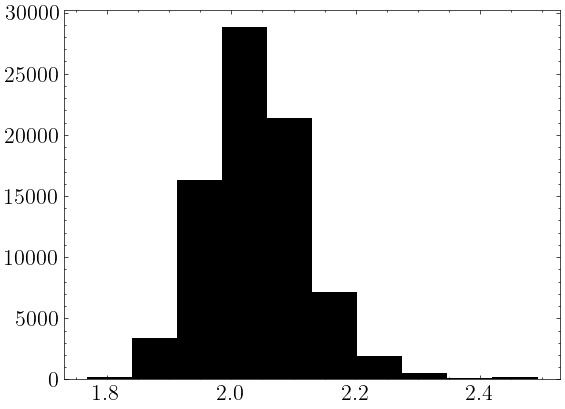

In [212]:
plt.hist(z_127_c2L_PIE_logt_rec)

In [213]:
get_quantiles(z_127_c2L_PIE_logt_rec)

2.04 -0.07 0.08


(array([ 2920.,  5392.,  8569., 11939., 15740., 14508., 12719.,  6691.,
         1288.,   234.]),
 array([-0.41385547, -0.29411037, -0.17436528, -0.05462019,  0.06512491,
         0.18487   ,  0.30461509,  0.42436018,  0.54410528,  0.66385037,
         0.78359546]),
 <BarContainer object of 10 artists>)

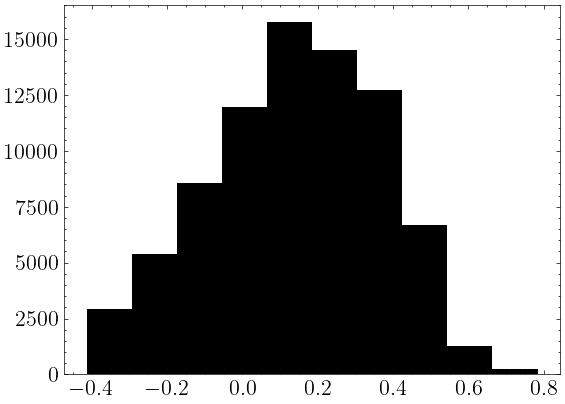

In [214]:
plt.hist(z_127_c2L_PIE_logt_cool-z_127_c2L_PIE_logt_rec)

In [215]:
get_quantiles(z_127_c2L_PIE_logt_cool-z_127_c2L_PIE_logt_rec)

0.15 -0.25 0.22


# Functions for TDP cooling

In [216]:
# TDP model grid points
log_metals_arr_TDP = [-2.6,-2.4,-2.2,-2.0,-1.8,-1.6,-1.4,-1.2,-1.0 ,-0.8,-0.6,-0.4,-0.2,0.0,0.2,0.4,0.6,0.8,1.0]
log_hdens_arr_TDP = [-4.8,-4.6,-4.4,-4.0,-3.8,-3.6,-3.4,-3.2,-3.0,-2.8,-2.6,-2.4,-2.2,-2.0,-1.8,-1.6]
logT_arr_TDP = np.arange(4.00, 6.01, 0.01)

Interpolate temperatures and cooling times

In [217]:
pkl_file = open(rootdir+'cloudy_grids/TDP_cool.pkl', 'rb')
log_cool_TDP_samples = pickle.load(pkl_file)
pkl_file.close()

In [218]:
log_cool_TDP_interp = RegularGridInterpolator((log_metals_arr_TDP, log_hdens_arr_TDP, logT_arr_TDP), log_cool_TDP_samples)

Functions to get TDP cooling times

In [219]:
def compute_tcool_TDP(log_metals, log_hdens, logT, log_cool_TDP_interp):
    
    Ctot = 10**log_cool_TDP_interp((log_metals, log_hdens, logT))
    
    # Equation from Gnat and Sternberg 2007
    t_cool = 4.34*1.5*(1.38*1e-16*10**logT)/(Ctot/10**log_hdens)
    
    return t_cool*t_Myr_sec

In [220]:
def get_cooling_dist_TDP(log_metals_samples, log_hdens_samples, logT_samples, logq_rec_interp, log_cool_TDP_interp):
    
    # Distribution of recombination times
    logt_rec_samples = logt_rec(log_hdens_samples, logT_samples, logq_rec_interp)
    
    # Distribution of cooling times
    logt_cool_samples = np.log10(compute_tcool_TDP(log_metals_samples, log_hdens_samples, logT_samples, log_cool_TDP_interp))
    
    return np.array(logt_rec_samples), np.array(logt_cool_samples)

# z=1.09

## c1

In [226]:
z_109_c1_TDP_samples = pd.read_csv(loaddir+'z=1.09456549/cloudy_fits/TDP.csv')

### c1H

In [237]:
z_109_c1H_TDP_logt_rec, z_109_c1H_TDP_logt_cool = get_cooling_dist_TDP(z_109_c1_TDP_samples['log_metals_p1'], 
                                                                   z_109_c1_TDP_samples['log_hdens_p1'],
                                                                   z_109_c1_TDP_samples['logT_p1'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([   96.,   757.,  2242.,  5398., 11835., 19974., 21613., 14395.,
         3305.,   385.]),
 array([0.72771653, 0.82759152, 0.92746651, 1.0273415 , 1.12721649,
        1.22709149, 1.32696648, 1.42684147, 1.52671646, 1.62659146,
        1.72646645]),
 <BarContainer object of 10 artists>)

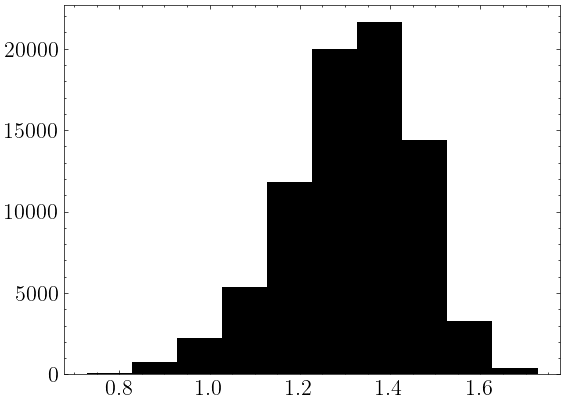

In [238]:
plt.hist(z_109_c1H_TDP_logt_rec)

In [239]:
get_quantiles(z_109_c1H_TDP_logt_rec)

1.33 -0.15 0.13


(array([  352.,  3828., 14848., 31102., 26071.,  3189.,   332.,   144.,
           97.,    37.]),
 array([0.16009394, 0.33267587, 0.50525781, 0.67783974, 0.85042167,
        1.02300361, 1.19558554, 1.36816747, 1.54074941, 1.71333134,
        1.88591328]),
 <BarContainer object of 10 artists>)

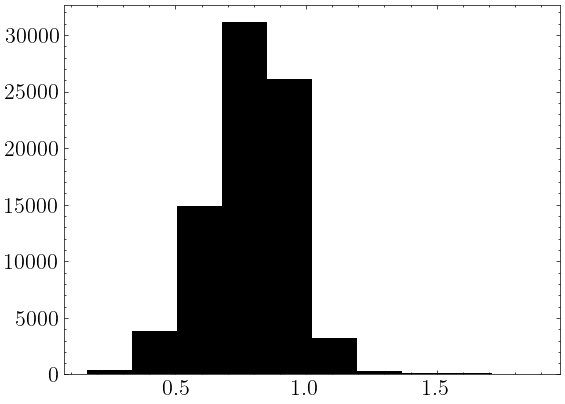

In [240]:
plt.hist(z_109_c1H_TDP_logt_cool-z_109_c1H_TDP_logt_rec)

In [241]:
get_quantiles(z_109_c1H_TDP_logt_cool-z_109_c1H_PIE_logt_rec)

1.26 -0.21 0.21


### c1L

In [242]:
z_109_c1L_TDP_logt_rec, z_109_c1L_TDP_logt_cool = get_cooling_dist_TDP(z_109_c1_TDP_samples['log_metals_p2'], 
                                                                   z_109_c1_TDP_samples['log_hdens_p2'],
                                                                   z_109_c1_TDP_samples['logT_p2'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([  162.,  1246.,  5342., 10376., 19934., 28342., 12280.,  1617.,
          504.,   197.]),
 array([1.56953375, 1.64848713, 1.72744051, 1.80639389, 1.88534727,
        1.96430065, 2.04325403, 2.12220741, 2.20116079, 2.28011417,
        2.35906755]),
 <BarContainer object of 10 artists>)

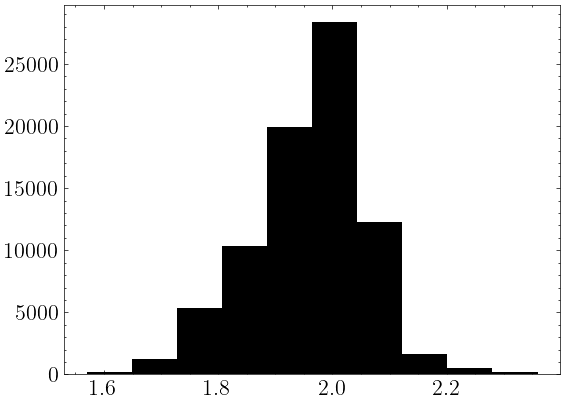

In [243]:
plt.hist(z_109_c1L_TDP_logt_rec)

In [244]:
get_quantiles(z_109_c1L_TDP_logt_rec)

1.97 -0.11 0.08


(array([  343.,  2140.,  8919., 13274., 15843., 15528., 12889.,  7437.,
         3410.,   217.]),
 array([-0.75919442, -0.62596083, -0.49272724, -0.35949364, -0.22626005,
        -0.09302646,  0.04020714,  0.17344073,  0.30667432,  0.43990792,
         0.57314151]),
 <BarContainer object of 10 artists>)

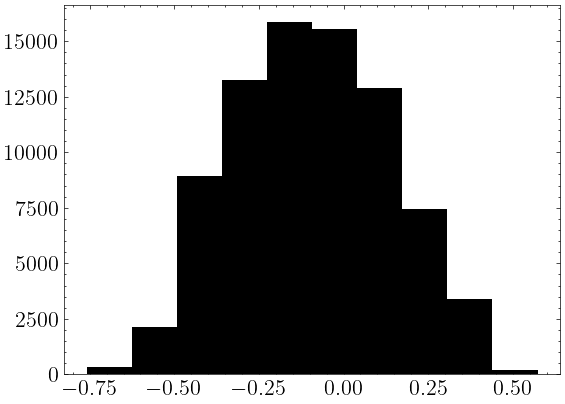

In [245]:
plt.hist(z_109_c1L_TDP_logt_cool-z_109_c1L_TDP_logt_rec)

In [247]:
get_quantiles(z_109_c1L_TDP_logt_cool-z_109_c1L_PIE_logt_rec)

0.3 -0.33 0.32


# z=1.26

## c1

In [248]:
z_126_c1_TDP_samples = pd.read_csv(loaddir+'z=1.25937492/cloudy_fits/TDP.csv')

In [249]:
z_126_c1_TDP_logt_rec, z_126_c1_TDP_logt_cool = get_cooling_dist_TDP(z_126_c1_TDP_samples['log_metals'], 
                                                                   z_126_c1_TDP_samples['log_hdens'],
                                                                   z_126_c1_TDP_samples['logT'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([1.7200e+03, 9.6940e+03, 1.7464e+04, 2.1047e+04, 1.6051e+04,
        9.4230e+03, 3.6780e+03, 7.8400e+02, 1.3300e+02, 6.0000e+00]),
 array([0.8296024 , 0.93958587, 1.04956934, 1.15955281, 1.26953628,
        1.37951975, 1.48950322, 1.59948669, 1.70947016, 1.81945363,
        1.9294371 ]),
 <BarContainer object of 10 artists>)

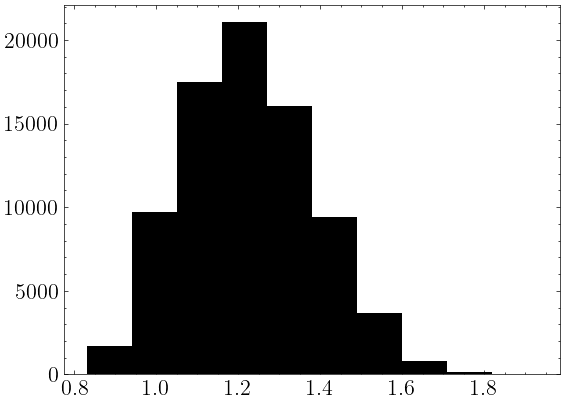

In [250]:
plt.hist(z_126_c1_TDP_logt_rec)

In [251]:
get_quantiles(z_126_c1_TDP_logt_rec)

1.22 -0.16 0.17


(array([6.7610e+03, 3.9808e+04, 2.7797e+04, 5.3240e+03, 3.0900e+02,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([-0.3809506 , -0.14841467,  0.08412126,  0.31665719,  0.54919312,
         0.78172905,  1.01426499,  1.24680092,  1.47933685,  1.71187278,
         1.94440871]),
 <BarContainer object of 10 artists>)

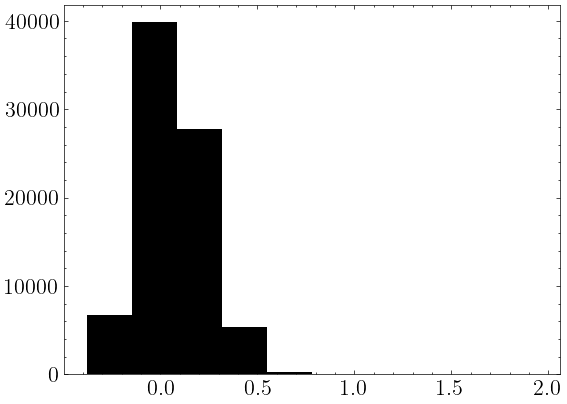

In [252]:
plt.hist(z_126_c1_TDP_logt_cool-z_126_c1_TDP_logt_rec)

In [253]:
get_quantiles(z_126_c1_TDP_logt_cool-z_126_c1_TDP_logt_rec)

0.05 -0.15 0.18


# z=1.27

## c1

In [255]:
z_127_c1_TDP_samples = pd.read_csv(loaddir+'z=1.27767328/cloudy_fits/TDP.csv')

### c1H

In [256]:
z_127_c1H_TDP_logt_rec, z_127_c1H_TDP_logt_cool = get_cooling_dist_TDP(z_127_c1_TDP_samples['log_metals_p1'], 
                                                                   z_127_c1_TDP_samples['log_hdens_p1'],
                                                                   z_127_c1_TDP_samples['logT_p1'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([  511.,   690.,  1069.,   893.,  1199.,  3518., 18961., 36292.,
        15002.,  1865.]),
 array([-0.37242994, -0.12372147,  0.124987  ,  0.37369548,  0.62240395,
         0.87111243,  1.1198209 ,  1.36852937,  1.61723785,  1.86594632,
         2.1146548 ]),
 <BarContainer object of 10 artists>)

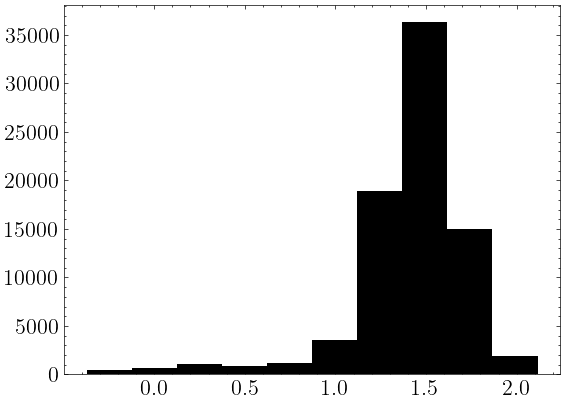

In [257]:
plt.hist(z_127_c1H_TDP_logt_rec)

In [258]:
get_quantiles(z_127_c1H_TDP_logt_rec)

1.46 -0.22 0.2


(array([4.6100e+02, 1.0140e+03, 4.3087e+04, 2.6480e+04, 8.5350e+03,
        2.4200e+02, 5.0000e+01, 5.4000e+01, 5.8000e+01, 1.9000e+01]),
 array([-0.34209264, -0.08324758,  0.17559748,  0.43444254,  0.6932876 ,
         0.95213266,  1.21097772,  1.46982278,  1.72866785,  1.98751291,
         2.24635797]),
 <BarContainer object of 10 artists>)

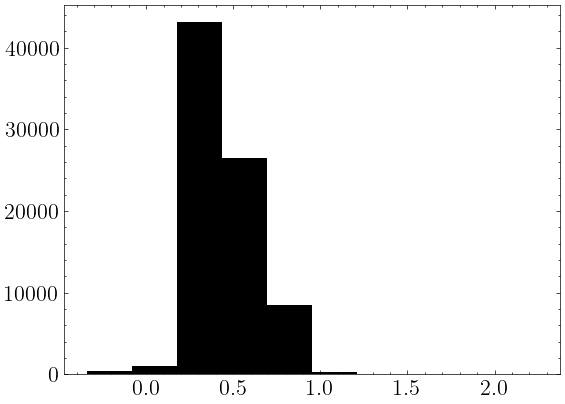

In [262]:
plt.hist(z_127_c1H_TDP_logt_cool-z_127_c1H_TDP_logt_rec)

In [263]:
get_quantiles(z_127_c1H_TDP_logt_cool-z_127_c1H_TDP_logt_rec)

0.41 -0.11 0.22


### c1L

In [264]:
z_127_c1L_TDP_logt_rec, z_127_c1L_TDP_logt_cool = get_cooling_dist_TDP(z_127_c1_TDP_samples['log_metals_p2'], 
                                                                   z_127_c1_TDP_samples['log_hdens_p2'],
                                                                   z_127_c1_TDP_samples['logT_p2'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([  403.,  1567.,  3916.,  6284., 14840., 24635., 20541.,  6748.,
          948.,   118.]),
 array([2.16996919, 2.2454429 , 2.3209166 , 2.3963903 , 2.471864  ,
        2.54733771, 2.62281141, 2.69828511, 2.77375881, 2.84923252,
        2.92470622]),
 <BarContainer object of 10 artists>)

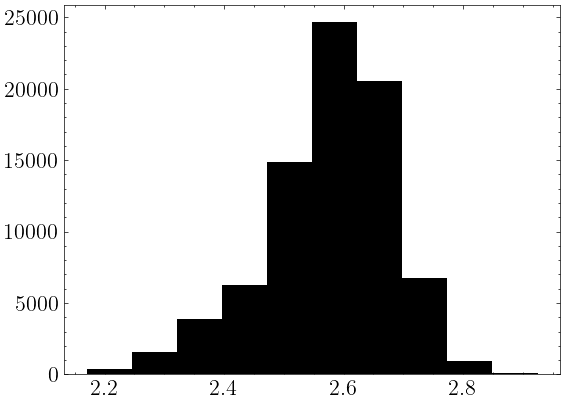

In [267]:
plt.hist(z_127_c1L_TDP_logt_rec)

In [268]:
get_quantiles(z_127_c1L_TDP_logt_rec)

2.59 -0.11 0.08


(array([ 1941., 10565., 20997., 17281., 13593.,  9068.,  4504.,  1613.,
          341.,    97.]),
 array([-0.65078799, -0.52503426, -0.39928053, -0.2735268 , -0.14777307,
        -0.02201934,  0.10373439,  0.22948812,  0.35524185,  0.48099558,
         0.60674931]),
 <BarContainer object of 10 artists>)

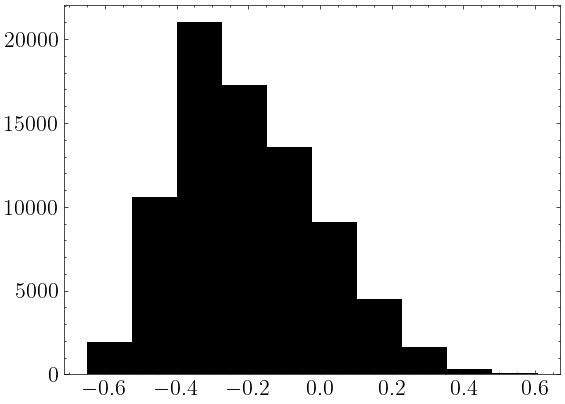

In [269]:
plt.hist(z_127_c1L_TDP_logt_cool-z_127_c1L_TDP_logt_rec)

In [270]:
get_quantiles(z_127_c1L_TDP_logt_cool-z_127_c1L_PIE_logt_rec)

1.77 -0.55 0.51


# DRAFT

# z=0.67

## c1

In [224]:
#z_067_c1_TDP_samples = pd.read_csv(loaddir+'z=0.67545705/cloudy_fits/TDP.csv')

### c1L

In [222]:
z_067_c1L_TDP_logt_rec, z_067_c1L_TDP_logt_cool = get_cooling_dist_TDP(z_067_c1_TDP_samples['log_metals_p1'], 
                                                                   z_067_c1_TDP_samples['log_hdens_p1'],
                                                                   z_067_c1_TDP_samples['logT_p1'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

NameError: name 'z_067_c1_TDP_samples' is not defined

(array([  233.,   596.,  2033.,  4992.,  8626., 11950., 19349., 23706.,
         8064.,   451.]),
 array([-0.40073044, -0.18844339,  0.02384366,  0.23613071,  0.44841776,
         0.66070481,  0.87299186,  1.08527891,  1.29756596,  1.509853  ,
         1.72214005]),
 <BarContainer object of 10 artists>)

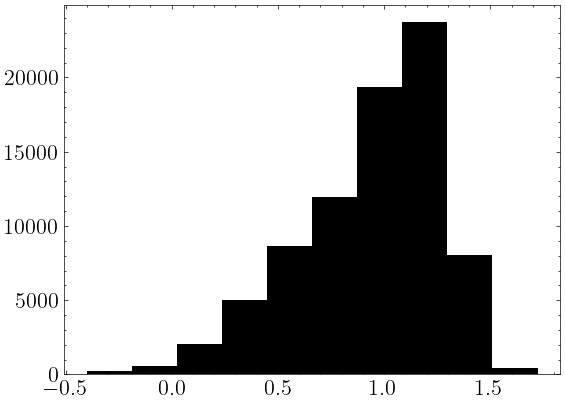

In [159]:
plt.hist(z_067_c1L_TDP_logt_rec)

In [160]:
get_quantiles(z_067_c1L_TDP_logt_rec)

1.01 -0.44 0.23


(array([9.6640e+03, 5.1838e+04, 1.7951e+04, 3.6900e+02, 7.8000e+01,
        3.3000e+01, 2.8000e+01, 3.8000e+01, 0.0000e+00, 1.0000e+00]),
 array([0.25529485, 0.52553135, 0.79576786, 1.06600436, 1.33624087,
        1.60647738, 1.87671388, 2.14695039, 2.41718689, 2.6874234 ,
        2.95765991]),
 <BarContainer object of 10 artists>)

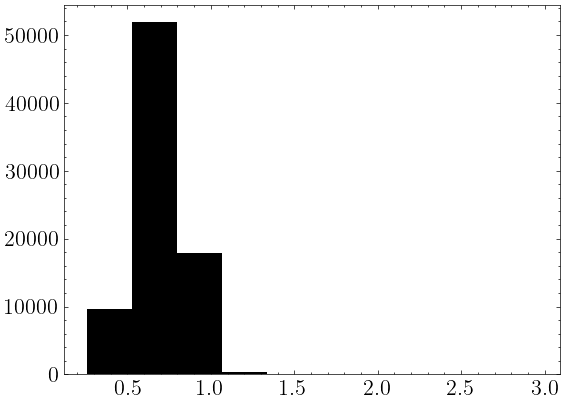

In [161]:
plt.hist(z_067_c1L_TDP_logt_cool-z_067_c1L_TDP_logt_rec)

In [162]:
get_quantiles(z_067_c1L_TDP_logt_cool-z_067_c1L_PIE_logt_rec)

0.9 -0.57 0.46


### c1H

In [163]:
z_067_c1H_TDP_logt_rec, z_067_c1H_TDP_logt_cool = get_cooling_dist_TDP(z_067_c1_TDP_samples['log_metals_p2'], 
                                                                   z_067_c1_TDP_samples['log_hdens_p2'],
                                                                   z_067_c1_TDP_samples['logT_p2'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([1.7100e+02, 7.7000e+02, 1.5050e+03, 3.8960e+03, 9.6570e+03,
        1.7084e+04, 2.8406e+04, 1.7417e+04, 1.0810e+03, 1.3000e+01]),
 array([1.75976289, 1.86707555, 1.97438821, 2.08170087, 2.18901353,
        2.29632619, 2.40363886, 2.51095152, 2.61826418, 2.72557684,
        2.8328895 ]),
 <BarContainer object of 10 artists>)

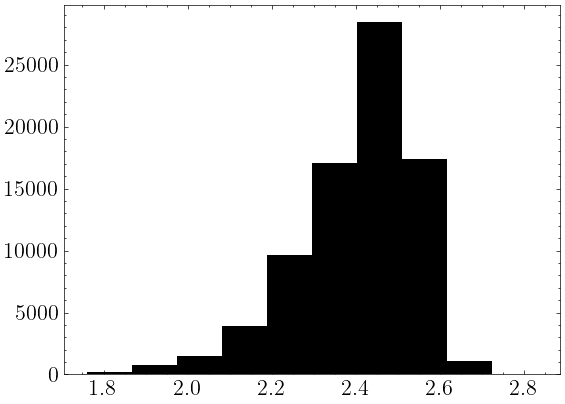

In [164]:
plt.hist(z_067_c1H_TDP_logt_rec)

In [165]:
get_quantiles(z_067_c1H_TDP_logt_rec)

2.43 -0.16 0.1


(array([  479.,  1612.,  2644.,  3592.,  6503., 11710., 23289., 23859.,
         5708.,   604.]),
 array([-0.79916646, -0.66226482, -0.52536319, -0.38846156, -0.25155993,
        -0.1146583 ,  0.02224334,  0.15914497,  0.2960466 ,  0.43294823,
         0.56984987]),
 <BarContainer object of 10 artists>)

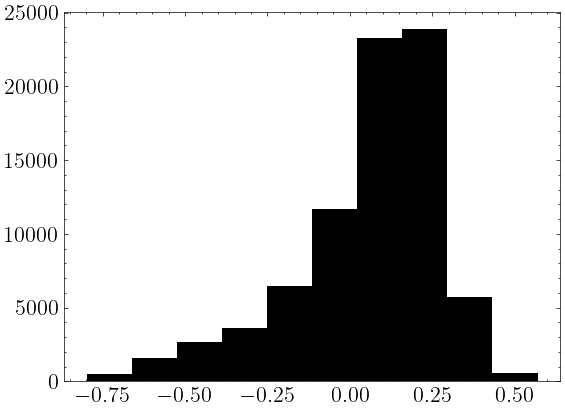

In [166]:
plt.hist(z_067_c1H_TDP_logt_cool-z_067_c1H_TDP_logt_rec)

In [167]:
get_quantiles(z_067_c1H_TDP_logt_cool-z_067_c1H_PIE_logt_rec)

0.57 -0.34 0.2
